# Calculating EKE, $\zeta$ and $\Delta SSH$ along the contour

We will in this notebook calcualte the Eddy Kinectic Energy (EKE), relative vortivity ($\zeta$) and standard deviation of SSh along the 1 km isobath of panans with different resolutiuon. The aim here is to save these variables to diagnose if we have more eddies in certain resolutuons

In [1]:
import cosima_cookbook as cc
import matplotlib.pyplot as plt
import cmocean as cm
import numpy as np
from dask.distributed import Client
from scipy.interpolate import interp1d
from xhistogram.xarray import histogram

import xarray as xr
import cf_xarray as cfxr

In [2]:
client = Client(n_workers=48, memory_limit='1400gb')

In [3]:
#setting the reference rho
rho_ref = 1035 #kg m^{-3}, used as standard by Pan-Antarctic

In [4]:
#panan sessions
session_p01 = cc.database.create_session('/home/156/wf4500/databases/access/panan01_HTsigma.db') #panan01
session_p005 = cc.database.create_session('/home/156/wf4500/databases/access/panan005_rerun.db') #panan005
session_p0025 = cc.database.create_session('/home/156/wf4500/databases/access/panan0025_rerun.db') #panan005



### 1. Calculating the Standard deviation of SSH

This provie a proxy for eddies, but also give a static picture of the signal, which is not ideal

In [ ]:
%%time
#Calculating delta SSH in panan01
SSH_01 = cc.querying.getvar('panan01_yr2000_HTsigma','zos',session_p01,frequency='1 daily',\
                            start_time='1999-01-01',end_time='2002-01-01',chunks={})
δSSH_01 = SSH_01.std('time').compute()
del SSH_01

In [ ]:
%%time
#Calculating delta SSH in panan005
SSH_005 = cc.querying.getvar('panan_005deg_jra55_ryf_2024_12_14','zos',session_p005,frequency='1 daily',\
                            start_time='1999-01-01',end_time='2002-01-01',chunks={})
δSSH_005 = SSH_005.std('time').compute()
del SSH_005

In [6]:
%%time
#Calculating delta SSH in panan005
SSH_0025 = cc.querying.getvar('mom6-panan','zos',session_p0025,frequency='1 daily',\
                            start_time='1999-01-01',end_time='2001-01-01',chunks={})
δSSH_0025 = SSH_0025.std('time').compute()
del SSH_0025

/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3.10/site-packages/dask/array/numpy_compat.py:56: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3.10/site-packages/dask/array/numpy_compat.py:56: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3.10/site-packages/dask/array/numpy_compat.py:56: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3.10/site-packages/dask/array/numpy_compat.py:56: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3.10/site-packages/dask/array/numpy_compat.py:56: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/g/data/hh5/pub

CPU times: user 2min, sys: 15.4 s, total: 2min 16s
Wall time: 2min 44s


Sanity check

Text(0.5, 1.0, 'Panan0025')

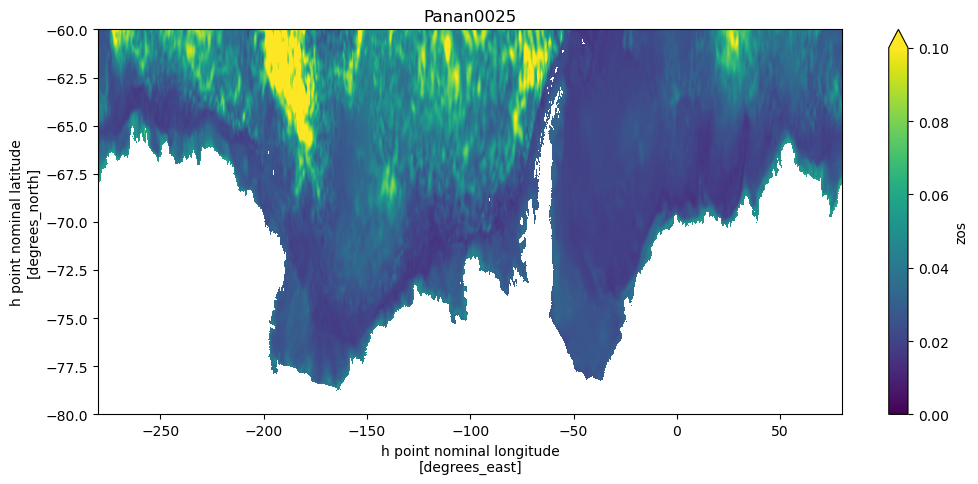

In [8]:
plt.figure(figsize=(12,5))

δSSH_0025.plot.pcolormesh(vmin=0,vmax=0.1)
plt.ylim(-80,-60)
plt.title('Panan0025')

Text(0.5, 1.0, '[b] Panan005')

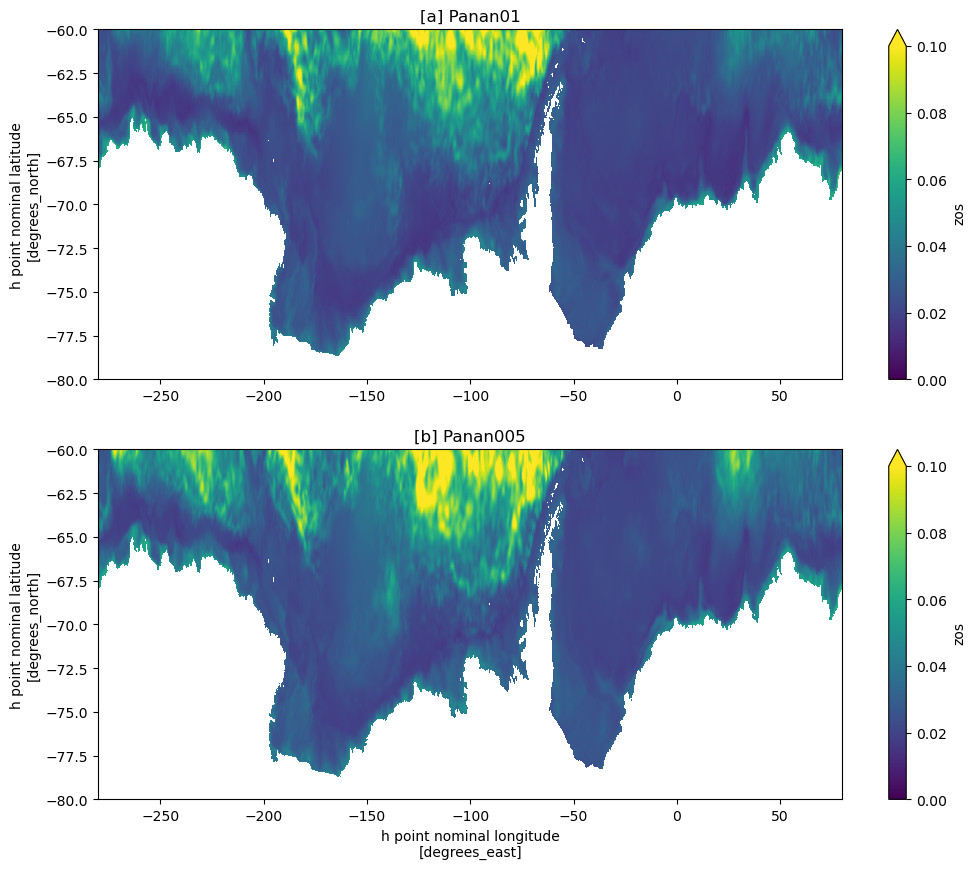

In [9]:
plt.figure(figsize=(12,10))


plt.subplot(2,1,1)
δSSH_01.plot.pcolormesh(vmin=0,vmax=0.1)
plt.title('[a] Panan01')
plt.ylim(-80,-60)
plt.xlabel('')

plt.subplot(2,1,2)
δSSH_005.plot.pcolormesh(vmin=0,vmax=0.1)
plt.ylim(-80,-60)
plt.title('[b] Panan005')

Saving files

In [9]:
δSSH_01.name= 'SSH_std'
δSSH_005.name= 'SSH_std'
δSSH_0025.name= 'SSH_std'

In [5]:
base_savedir = '/g/data/ik11/users/wf4500/Project_panan/GH/Panan_HT_ASC/Processed_data/'

δSSH_01.to_netcdf(base_savedir + 'panan01_rerun/EKE_along_contour/SSH_std_map_panan01.nc')
δSSH_005.to_netcdf(base_savedir + 'panan005_rerun/EKE_along_contour/SSH_std_map_panan005.nc')
δSSH_0025.to_netcdf(base_savedir + 'panan0025_rerun/EKE_along_contour/SSH_std_map_panan0025.nc')

## 2. Panan01 Vorticity and EKE

### 2.1 Panan01 Vorticity


We will calculate the vorticity separately between resolutions, to avoid memory issues. First, let's do it for panan01

We will need first to get the $dx$'s and $dy$'s of panan01

In [6]:
#dxs in all grid points
dx_xhyh_01 = cc.querying.getvar('panan01_yr2000_HTsigma','dxt',session_p01,ncfile='19990101.ocean_static.nc')
dx_xqyh_01 = cc.querying.getvar('panan01_yr2000_HTsigma','dxCu',session_p01,ncfile='19990101.ocean_static.nc')
dx_xhyq_01 = cc.querying.getvar('panan01_yr2000_HTsigma','dxCv',session_p01,ncfile='19990101.ocean_static.nc')
dx_xqyq_01 = dx_xhyh_01.rename({'xh':'xq','yh':'yq'}).copy()
dx_xqyq_01 =  xr.concat([dx_xqyq_01 [:,-1],dx_xqyq_01 ], dim='xq')
dx_xqyq_01['yq'] = dx_xhyq_01.yq[:-1]
dx_xqyq_01['xq'] = dx_xqyh_01.xq

#dys in all grid points
dy_xhyh_01 = cc.querying.getvar('panan01_yr2000_HTsigma','dyt',session_p01,ncfile='19990101.ocean_static.nc')
dy_xqyh_01 = cc.querying.getvar('panan01_yr2000_HTsigma','dyCu',session_p01,ncfile='19990101.ocean_static.nc')
dy_xhyq_01 = cc.querying.getvar('panan01_yr2000_HTsigma','dyCv',session_p01,ncfile='19990101.ocean_static.nc')
dy_xqyq_01 = dy_xhyh_01.rename({'xh':'xq','yh':'yq'}).copy()
dy_xqyq_01=  xr.concat([dy_xqyq_01[:,-1],dy_xqyq_01], dim='xq')
dy_xqyq_01['yq'] = dy_xhyq_01.yq[:-1]
dy_xqyq_01['xq'] = dy_xqyh_01.xq


Let's import the surface $U$ and $V$ of panan01

In [6]:
#Getting U and V at surface
Us_01 = cc.querying.getvar('panan01_yr2000_HTsigma','uo',session_p01,frequency='1 daily',\
                            start_time='1999-01-01',end_time='2002-01-01',chunks={}).mean('z_l_sub01')
Vs_01 = cc.querying.getvar('panan01_yr2000_HTsigma','vo',session_p01,frequency='1 daily',\
                            start_time='1999-01-01',end_time='2002-01-01',chunks={}).mean('z_l_sub01')

We have everything necessary to calcualte the vorticity first, so let's do that.

In [12]:
%%time
##### Part 1 of vorticity, dv/dx

# We need to make diff('xh') on V, but to make sure the V's are correct, a Halo is
#first created on the eastern and western side of the domain
dVs_01 = xr.concat([Vs_01[:,:,-1],Vs_01,Vs_01[:,:,0]], dim='xh').diff('xh')
#the resulting data is on xq now, so let's fix that
dVs_01 = dVs_01.rename({'xh':'xq'})
dVs_01['xq'] = Us_01.xq
#now let's devide Dvs (delta done along x's) by the x distances to get dVdx.
#This velow is the first term of the vorticity
dVdx_01 = (dVs_01/dx_xqyq_01).compute()


CPU times: user 1min 19s, sys: 30.8 s, total: 1min 50s
Wall time: 1min 47s


In [13]:
%%time
##### Part 2 of vorticity, du/dy

# analogous to Dv, We need to make diff('yh') on U, but to make sure the U's 
#in this case however, we know the domain is not reentrant in y, so we can just
#make the calculation while getting rid of the Southernmost latitude.
#that is not a problem here because the Southernmost latitude is popualted by NaNs
dUs_01 = Us_01.diff('yh')
#the resulting data is on xq now, so let's fix that
dUs_01 = dUs_01.rename({'yh':'yq'})
dUs_01['yq'] = Vs_01.yq[1:-1]
#now let's devide Dus (delta done along y's) by the y distances to get dVdx.
#This below is the second term of the vorticity
dUdy_01 = (dUs_01/dy_xqyq_01).compute()

CPU times: user 1min 6s, sys: 26.7 s, total: 1min 33s
Wall time: 1min 29s


Let's then finally calculate the vorticity

In [14]:
ζ_01 = dVdx_01 - dUdy_01
ζ_01.name = 'Surface_Vorticity'

Sanity check.... does it look reasonable?

(-80.0, -60.0)

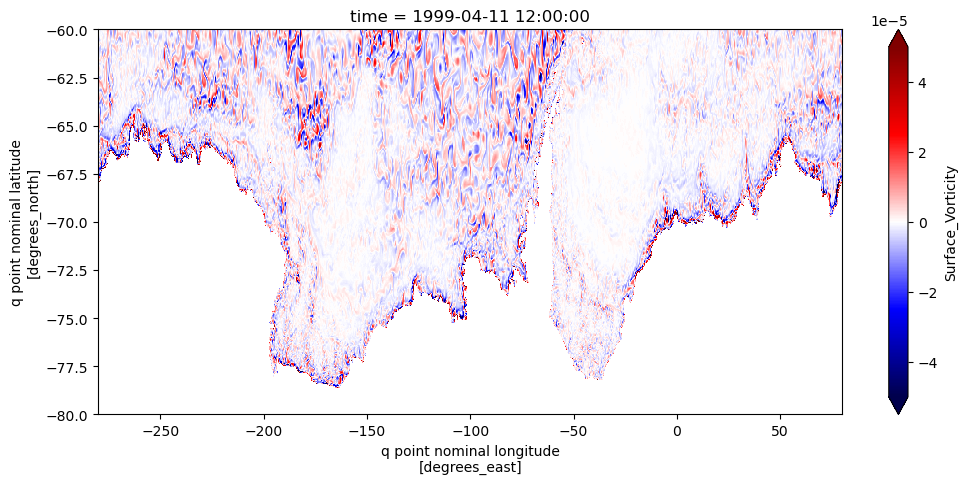

In [15]:
valmag= 5e-5
plt.figure(figsize=(12,5))
ζ_01.isel(time=100).plot(vmin=-valmag,vmax=valmag,cmap='seismic')
plt.ylim(-80,-60)

Let's now save that data

In [16]:

ζ_01.to_netcdf(base_savedir + 'panan01_rerun/EKE_along_contour/vorticity_xyt_panan01.nc')


And let's now extract the vorticity along the isobath and save it too

In [39]:
#panan01 daily as HT f(z,time) to colocate the isoabth points
src_p01 = '/g/data/ik11/users/wf4500/Project_panan/GH/Panan_HT_ASC/Processed_data/panan01_rerun/CSHT_month_rhoonline/*'

#importing panan01
import glob
gl =glob.glob(src_p01)
gl=sorted(gl)
p01_HTmean=xr.open_mfdataset(gl, concat_dim='time', combine='nested').mean('time').compute()

The lon and lat along the isobath are not the same between the vorticity and heat transports. Heat transports are on the directional sides of the grid, while the vorticity is on the corners of the grid. The best way I have to find these values is to use interp to extract values of vorticity along the isobath

In [18]:
ζ_01_along_contour = ζ_01.interp(xq = p01_HTmean.lon_along_contour, yq =p01_HTmean.lat_along_contour)

Saving $\zeta$ along contour for panan01

In [19]:

ζ_01_along_contour.to_netcdf(base_savedir + 'panan01_rerun/EKE_along_contour/vorticity_along_contour_panan01.nc')


It might be important to keep in mind that we will have one problem here. We use a 3 degree bin standard to analyze the CSHT. However, if we use the 3 degree standard for the vorticity, we will smooth out the eddies, which we don't want. Maybe do a Vorticity vs EKE analysis , and the a EKE vs CSHT analysis, since EKE can just me summed in the 3 degree bins

### 2.2 Panan01 EKE

To calcualte the EKE we will need to make sure U and V are in the same grid spot. So let's first interpolate surface U and V into the *q* central points of the Grid

In [5]:
#Getting U and V at surface
Us_01 = cc.querying.getvar('panan01_yr2000_HTsigma','uo',session_p01,frequency='1 daily',\
                            start_time='1999-01-01',end_time='2002-01-01',chunks={}).mean('z_l_sub01')
Vs_01 = cc.querying.getvar('panan01_yr2000_HTsigma','vo',session_p01,frequency='1 daily',\
                            start_time='1999-01-01',end_time='2002-01-01',chunks={}).mean('z_l_sub01')

In [6]:
#Getting U and V at surface monthly, for monthly climatology, using the 10 years of simulation
Us_01_monthly_climatology = cc.querying.getvar('panan01_yr2000_HTsigma','uo',session_p01,frequency='1 monthly',\
                            start_time='1991-01-01',end_time='2002-01-01',chunks={}).isel(z_l=0).groupby('time.month').mean().compute()
Vs_01_monthly_climatology = cc.querying.getvar('panan01_yr2000_HTsigma','vo',session_p01,frequency='1 monthly',\
                            start_time='1991-01-01',end_time='2002-01-01',chunks={}).isel(z_l=0).groupby('time.month').mean().compute()

In [7]:
#interpolating U and U_clim
Us_01_qpoint = Us_01.interp(yh = Vs_01.yq).drop_vars('yh')
Us_01_qpoint_monthly_climatology = Us_01_monthly_climatology.interp(yh = Vs_01_monthly_climatology.yq).drop_vars('yh')
#interpolating v
Vs_01_qpoint = Vs_01.interp(xh = Us_01.xq).drop_vars('xh')
Vs_01_qpoint_monthly_climatology = Vs_01_monthly_climatology.interp(xh = Us_01_monthly_climatology.xq).drop_vars('xh')

Now that $U$ and $V$ are in the same grid point, we can calculate the 3-monthly mean that will be used as a reference to calculate their anomaly $U'$ and $V'$

In [8]:
#defining the months bin edges for averaging
bin_edges=[-0.5,2.5,5.5,8.5,11.5]
#those bins will separate months as in DJF = 0,1,2; MAM = 3,4,5; etc

In [9]:
# first mean qpoint for u
#calculating monthly mean
Us_01_monthlymean0 = Us_01_qpoint.groupby('time.month').mean()
#creating halo in months
Us_01_monthlymean = xr.concat([Us_01_monthlymean0.sel(month=12),Us_01_monthlymean0.isel(month=slice(0,11))], dim='month')
#fixing month coordinate
Us_01_monthlymean['month'] = np.arange(0,12)
#for showing what we did with the climatology
Us_01_monthlymean0 =  xr.concat([Us_01_monthlymean0.sel(month=12),Us_01_monthlymean0,Us_01_monthlymean0.sel(month=1)], dim='month')
Us_01_monthlymean0['month'] = np.arange(0,14)

#Binning according to season
Us_01_season = Us_01_monthlymean.groupby_bins('month', bins=bin_edges).mean()

#propagating into 12 months for 
Us_01_season_interp  =  xr.concat([Us_01_season.isel(month_bins=0),\
                                  Us_01_season.isel(month_bins=0),
                                  Us_01_season.isel(month_bins=1),
                                  Us_01_season.isel(month_bins=1),
                                  Us_01_season.isel(month_bins=1),
                                  Us_01_season.isel(month_bins=2),
                                  Us_01_season.isel(month_bins=2),
                                  Us_01_season.isel(month_bins=2),
                                  Us_01_season.isel(month_bins=3),
                                  Us_01_season.isel(month_bins=3),
                                  Us_01_season.isel(month_bins=3),
                                  Us_01_season.isel(month_bins=0)], dim='month_bins')
Us_01_season_interp['month_bins'] = np.arange(1,13)



Now lets calculate the $U'$

In [10]:
%%time
Us_01_qpoint.load()
Us_01_qpoint_monthly_climatology.load()
Us_01_season_interp.load()
print('Loading the data for a faster, less memory-intensive loop')

Loading the data for a faster, less memory-intensive loop
CPU times: user 1min 3s, sys: 42.1 s, total: 1min 45s
Wall time: 1min 43s


In [11]:
from tqdm import tqdm
#Calculating the anomalies from the climatology
base_savedir = '/g/data/ik11/users/wf4500/Project_panan/GH/Panan_HT_ASC/Processed_data/'

#first and last time of the month, to separate data and remove the seasonal climatology
Initial_timesstamp = Us_01_qpoint.time.resample(time ='1M').min()
Final_timesstamp = Us_01_qpoint.time.resample(time ='1M').max()
loop_extent = Final_timesstamp.shape[0] # number of indexes to loop through when doing the calculation

#Looping through months to calculate the anomaly
for n in tqdm(range(loop_extent)):
    Us_01_qpoint_thismonth = Us_01_qpoint.sel(time=slice(Initial_timesstamp[n],Final_timesstamp[n]))
    #print(Initial_timesstamp[n].time.dt.strftime('%Y-%m-%d').values.tolist()[:7])
    #here 1 is January
    month_identifier = Us_01_qpoint_thismonth.time.groupby('time.month').mean().month[0].values
    Us_01_qpoint_ano_thismonth = Us_01_qpoint_thismonth - Us_01_qpoint_monthly_climatology.sel(month = month_identifier)
    Us_01_qpoint_ano_thismonth_seasonal = Us_01_qpoint_thismonth - Us_01_season_interp.sel(month_bins = month_identifier)
    ITNC = Initial_timesstamp[n].time.dt.strftime('%Y-%m-%d').values.tolist()
    Us_01_qpoint_ano_thismonth.to_netcdf(base_savedir + 'panan01_rerun/EKE_along_contour/'+\
                                         'Uanom_xyt_' + ITNC[:7] + '_panan01.nc')
    Us_01_qpoint_ano_thismonth_seasonal.to_netcdf(base_savedir + 'panan01_rerun/EKE_along_contour/'+\
                                         'Uanom_seasonal_xyt_' + ITNC[:7] + '_panan01.nc')

100%|██████████| 36/36 [01:36<00:00,  2.67s/it]


In [12]:
Us_01_qpoint_ano = xr.open_mfdataset(base_savedir + 'panan01_rerun/EKE_along_contour/'+\
                                         'Uanom_xyt_*_panan01.nc').uo
Us_01_qpoint_ano_seasonal = xr.open_mfdataset(base_savedir + 'panan01_rerun/EKE_along_contour/'+\
                                         'Uanom_seasonal_xyt_*_panan01.nc').uo

Us_01_qpoint_ano_spatialmean = Us_01_qpoint_ano.mean(('xq','yq')).compute()
Us_01_qpoint_ano_seasonal_spatialmean = Us_01_qpoint_ano_seasonal.mean(('xq','yq')).compute()
Us_01_qpoint_spatialmean = Us_01_qpoint.mean(('xq','yq')).compute()

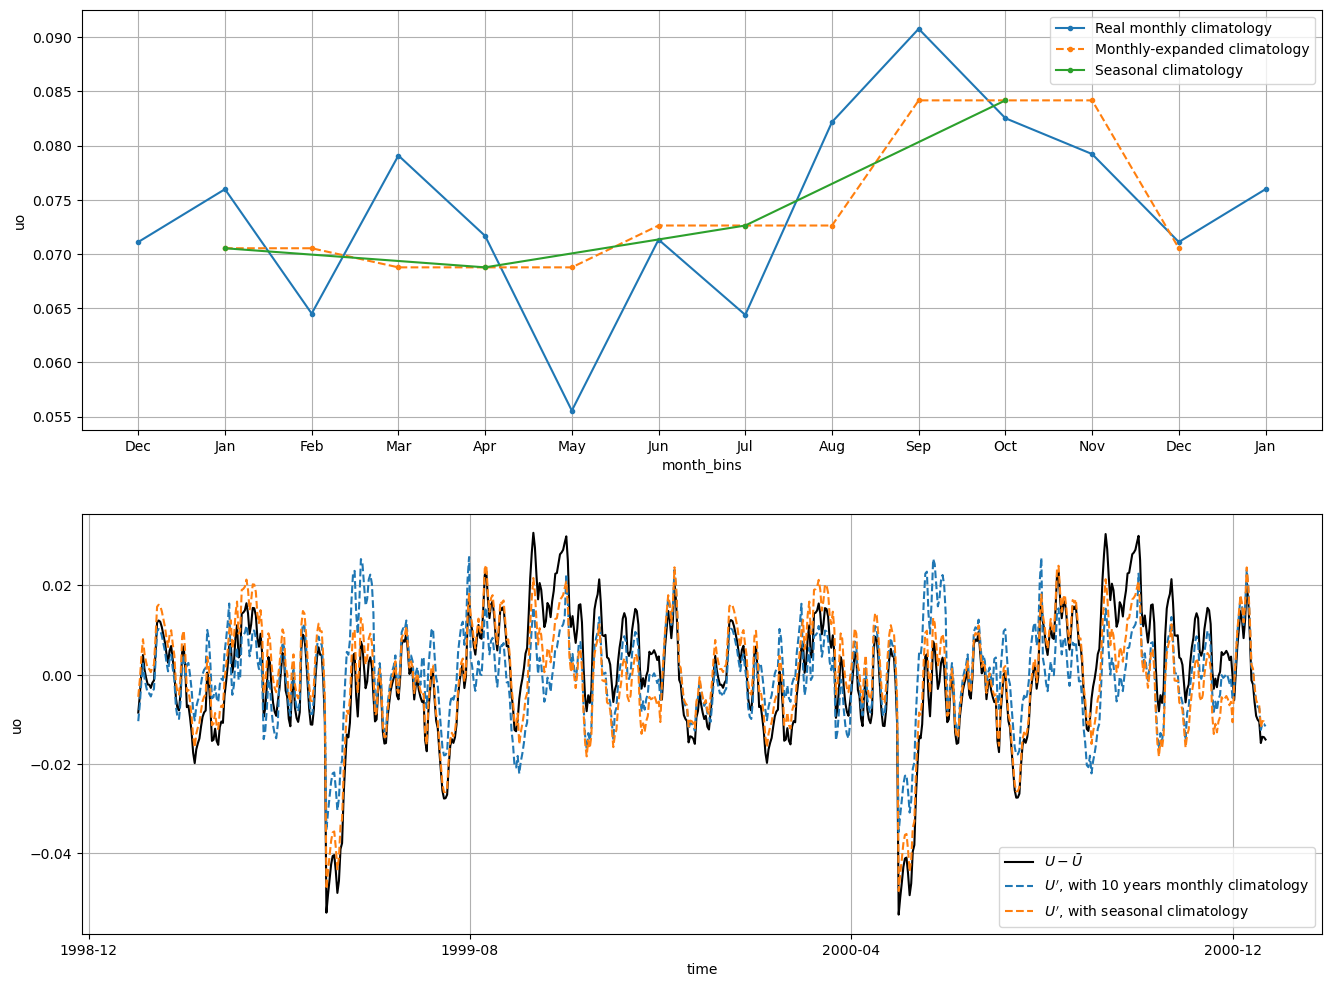

In [30]:
#Demonstrating the interpolation done for smoothing the data
test  =  Us_01_season.mean(('xq','yq'))
test_monthly  =  Us_01_monthlymean0.mean(('xq','yq'))
test  =  xr.concat([test.isel(month_bins = -1),test,test.isel(month_bins = 0)], dim='month_bins')
test['month_bins'] = [-3,0,3,6,9,12]
test.load()
test_righttime = test.isel(month_bins= slice(1,5)).compute()
test_righttime['month_bins'] = [1,4,7,10]
test_interp = Us_01_season_interp.mean(('xq','yq')).compute()

plt.figure(figsize=(16,12))

plt.subplot(2,1,1)
test_monthly.plot(marker = '.', label = 'Real monthly climatology')
test_interp.plot(linestyle = '--',marker = '.', label = 'Monthly-expanded climatology')
test_righttime.plot(marker = '.', label = 'Seasonal climatology')
plt.xticks(ticks=np.arange(0,14),labels=['Dec','Jan','Feb','Mar','Apr','May',\
          'Jun','Jul','Aug','Sep','Oct','Nov','Dec','Jan'])
plt.legend()
plt.grid()

plt.subplot(2,1,2)
(Us_01_qpoint_spatialmean - Us_01_qpoint_spatialmean.mean('time')).isel(time=slice(0,720)).plot(label=r"$U - \bar{U}$",color='black')
Us_01_qpoint_ano_spatialmean.isel(time=slice(0,720)).plot(label=r"$U'$, with 10 years monthly climatology",color='tab:blue',linestyle='--')
Us_01_qpoint_ano_seasonal_spatialmean.isel(time=slice(0,720)).plot(label=r"$U'$, with seasonal climatology",color='tab:orange',linestyle='--')
plt.legend()
plt.grid()

Using the 3-monthly climatology, makes me feel like we are amplyfying a lot of the seasonal signal we see in may. I try to use instead the 10 years mean monthly climatology

In [32]:
%%time
Vs_01_qpoint.load()
Vs_01_qpoint_monthly_climatology.load()
print('loading V values for faster loop')

CPU times: user 51.3 s, sys: 46.4 s, total: 1min 37s
Wall time: 1min 24s


<xarray.DataArray 'vo' (month: 12, yq: 846, xq: 3601)> Size: 292MB
array([[[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        ...,
        [        nan,  0.06087209,  0.06317625, ...,  0.04849814,
          0.05058676,         nan],
        [        nan,  0.06253188,  0.06457802, ...,  0.0487802 ,
          0.04899879,         nan],
        [        nan,  0.05877057,  0.06004963, ...,  0.04595781,
          0.04669721,         nan]],

       [[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
...
        [        nan,  0.04033852,  0.0386415 , ...,  0.0491566 ,
          0.046085  ,         nan],
        [        nan,  0.0352633 ,  0.03583315, ...,  0.04414764,
          0.03980841,         nan],
        [        nan,  0.03053757,  0.03140423, ...,  0.04078704,
          0.03600937,         nan]],

       [[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        ...,
        [        nan,  0.03839773,  0.04208023, ...,  0.0241326 ,
          0.02631648,         nan],
        [        nan,  0.04027861,  0.04453601, ...,  0.01862311,
          0.02079891,         nan],
        [        nan,  0.03817493,  0.04190457, ...,  0.01565444,
          0.01891687,         nan]]])
Coordinates:
    z_l      float64 8B 0.5413
  * yq       (yq) float64 7kB -81.13 -81.09 -81.05 -81.0 ... -37.26 -37.18 -37.1
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * xq       (xq) float64 29kB -280.0 -279.9 -279.8 -279.7 ... 79.8 79.9 80.0
Attributes:
    units:          m s-1
    long_name:      Sea Water Y Velocity
    cell_methods:   z_l:mean yq:point xh:mean time: mean
    time_avg_info:  average_T1,average_T2,average_DT
    standard_name:  sea_water_y_velocity
    interp_method:  none
    ncfiles:        ['/scratch/oz91/wf4500/panan01_year1999rerun_HTsigma/wf45...

In [33]:
# Doing now the same for V, ONLY USING MONTHLY CLIMATOLOGY
#first and last time of the month, to separate data and remove the seasonal climatology
Initial_timesstamp = Us_01_qpoint.time.resample(time ='1M').min()
Final_timesstamp = Us_01_qpoint.time.resample(time ='1M').max()
loop_extent = Final_timesstamp.shape[0] # number of indexes to loop through when doing the calculation

#Looping through months to calculate the anomaly
for n in tqdm(range(loop_extent)):
    Vs_01_qpoint_thismonth = Vs_01_qpoint.sel(time=slice(Initial_timesstamp[n],Final_timesstamp[n]))
    #print(Initial_timesstamp[n].time.dt.strftime('%Y-%m-%d').values.tolist()[:7])
    #here 1 is January
    month_identifier = Vs_01_qpoint_thismonth.time.groupby('time.month').mean().month[0].values
    Vs_01_qpoint_ano_thismonth = Vs_01_qpoint_thismonth - Vs_01_qpoint_monthly_climatology.sel(month = month_identifier)
    ITNC = Initial_timesstamp[n].time.dt.strftime('%Y-%m-%d').values.tolist()
    Vs_01_qpoint_ano_thismonth.to_netcdf(base_savedir + 'panan01_rerun/EKE_along_contour/'+\
                                         'Vanom_xyt_' + ITNC[:7] + '_panan01.nc')


INFO:flox:Entering _validate_reindex: reindex is None
INFO:flox:Leaving _validate_reindex: method = None, returning None
INFO:flox:_choose_engine: Choosing 'flox'

INFO:flox:Entering _validate_reindex: reindex is None
INFO:flox:Leaving _validate_reindex: method = None, returning None
INFO:flox:_choose_engine: Choosing 'flox'
  0%|          | 0/36 [00:00<?, ?it/s]INFO:flox:Entering _validate_reindex: reindex is None
INFO:flox:Leaving _validate_reindex: method = None, returning None
INFO:flox:_choose_engine: Choosing 'flox'
  3%|▎         | 1/36 [00:01<00:48,  1.38s/it]INFO:flox:Entering _validate_reindex: reindex is None
INFO:flox:Leaving _validate_reindex: method = None, returning None
INFO:flox:_choose_engine: Choosing 'flox'
  6%|▌         | 2/36 [00:02<00:42,  1.26s/it]INFO:flox:Entering _validate_reindex: reindex is None
INFO:flox:Leaving _validate_reindex: method = None, returning None
INFO:flox:_choose_engine: Choosing 'flox'
  8%|▊         | 3/36 [00:05<01:12,  2.19s/it]INFO:fl

In [34]:
#LOADING V AND U ANOMALIES
Vs_01_qpoint_ano = xr.open_mfdataset(base_savedir + 'panan01_rerun/EKE_along_contour/'+\
                                         'Vanom_xyt_*_panan01.nc').vo

Us_01_qpoint_ano.load()
Vs_01_qpoint_ano.load()

<xarray.DataArray 'vo' (time: 1095, yq: 846, xq: 3601)> Size: 27GB
array([[[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        ...,
        [        nan, -0.1038215 , -0.10431592, ..., -0.09346101,
         -0.0961853 ,         nan],
        [        nan, -0.11908532, -0.11972502, ..., -0.10112786,
         -0.10390845,         nan],
        [        nan, -0.06911609, -0.06390001, ..., -0.05351725,
         -0.05760618,         nan]],

       [[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
...
        [        nan,  0.06256514,  0.061351  , ...,  0.06277214,
          0.06419304,         nan],
        [        nan,  0.0667677 ,  0.06622901, ...,  0.06452931,
          0.06409836,         nan],
        [        nan,  0.04648721,  0.04570457, ...,  0.04739865,
          0.04889285,         nan]],

       [[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        ...,
        [        nan, -0.03563272, -0.03410778, ..., -0.04587972,
         -0.0437302 ,         nan],
        [        nan, -0.04411668, -0.0382187 , ..., -0.05219381,
         -0.05235377,         nan],
        [        nan, -0.02992042, -0.0351246 , ..., -0.02954363,
         -0.01393975,         nan]]])
Coordinates:
  * time     (time) object 9kB 1999-01-01 12:00:00 ... 2001-12-31 12:00:00
  * yq       (yq) float64 7kB -81.13 -81.09 -81.05 -81.0 ... -37.26 -37.18 -37.1
  * xq       (xq) float64 29kB -280.0 -279.9 -279.8 -279.7 ... 79.8 79.9 80.0
    z_l      float64 8B 0.5413
    month    (time) int64 9kB 1 1 1 1 1 1 1 1 1 1 ... 12 12 12 12 12 12 12 12 12

We can now calculate the surface EKE using these anomalies

In [35]:
%%time
EKE_01_surf  = 0.5 * ( (Us_01_qpoint_ano**2) + (Vs_01_qpoint_ano**2) ).compute()

CPU times: user 1min 7s, sys: 1min 10s, total: 2min 18s
Wall time: 1min 32s


(-80.0, -60.0)

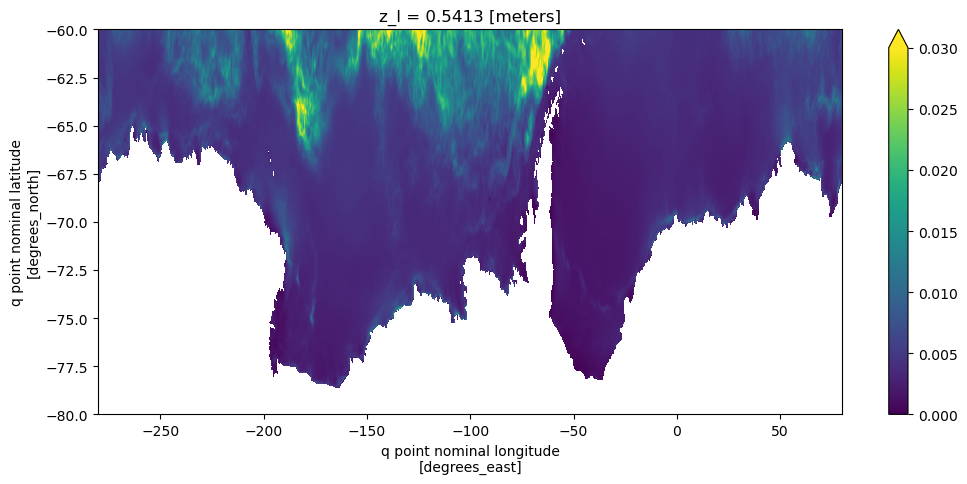

In [40]:
plt.figure(figsize=(12,5))
EKE_01_surf.mean('time').plot(vmin=0,vmax=.03)
plt.ylim(-80,-60)

Does high vorticity hotspots have high EKE?

(-4e-05, 4e-05)

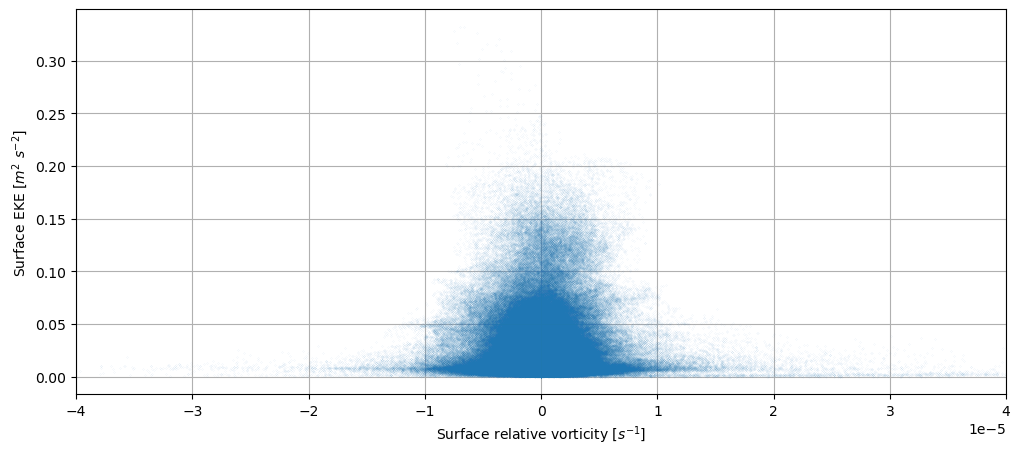

In [24]:
plt.figure(figsize=(12,5))
plt.plot(np.array(ζ_01.mean('time')).flatten(),np.array(EKE_01_surf.mean('time')[1:-1,:]).flatten(),\
        linestyle='none',marker='.',markersize = .05)
plt.grid()
plt.xlabel(r'Surface relative vorticity [$s^{-1}$]')
plt.ylabel(r'Surface EKE [$m^{2} \ s^{-2}$]')
plt.xlim(-4e-5,4e-5)

Saving EKE(x,y,t)

In [41]:

EKE_01_surf.to_netcdf(base_savedir + 'panan01_rerun/EKE_along_contour/EKE_xyt_panan01.nc')


Let's now extract EKE along the isobath the same way we did for the vorticity

In [42]:

EKE_01_along_contour = EKE_01_surf.interp(xq = p01_HTmean.lon_along_contour, yq =p01_HTmean.lat_along_contour)


Saving EKE along contour

In [43]:

EKE_01_along_contour.to_netcdf(base_savedir + 'panan01_rerun/EKE_along_contour/EKE_along_contour_panan01.nc')


2025-02-10 13:28:35,288 - distributed.worker - ERROR - Failed to communicate with scheduler during heartbeat.
Traceback (most recent call last):
  File "/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3.10/site-packages/distributed/comm/tcp.py", line 225, in read
    frames_nosplit_nbytes_bin = await stream.read_bytes(fmt_size)
tornado.iostream.StreamClosedError: Stream is closed

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3.10/site-packages/distributed/worker.py", line 1250, in heartbeat
    response = await retry_operation(
  File "/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3.10/site-packages/distributed/utils_comm.py", line 459, in retry_operation
    return await retry(
  File "/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3.10/site-packages/distributed/utils_comm.py", line 438, in retry


In [13]:
#clearing out the memory for Panan005 calculation
del EKE_01_along_contour, EKE_01_surf, ζ_01, ζ_01_along_contour
del Us_01, Us_01_qpoint, Us_01_qpoint_ano
del Vs_01, Vs_01_qpoint, Vs_01_qpoint_ano
del dUdy_01, dUs_01, dVdx_01, dVs_01, dx_xhyh_01, dx_xhyq_01
del dx_xqyh_01, dx_xqyq_01, dy_xhyh_01, dy_xhyq_01, dy_xqyh_01,dy_xqyq_01
del p01_HTmean, δSSH_01, δSSH_005

## 3. Panan005 Vorticity and EKE

### 3.1 Panan005 Vorticity

We can do all the same stuff for Panan005

In [7]:
#Getting U and V at surface
Us_005 = cc.querying.getvar('panan_005deg_jra55_ryf_2024_12_14','uo',session_p005,frequency='1 daily',\
                            start_time='1999-01-01',end_time='2002-01-01',chunks={}).mean('z_l_sub01').compute()
Vs_005 = cc.querying.getvar('panan_005deg_jra55_ryf_2024_12_14','vo',session_p005,frequency='1 daily',\
                            start_time='1999-01-01',end_time='2002-01-01',chunks={}).mean('z_l_sub01').compute()


2025-02-10 13:43:13,340 - distributed.worker.state_machine - WARNING - Async instruction for <Task cancelled name="execute('open_dataset-f2649c81-ca71-40ea-a94b-9591eeb4e742')" coro=<Worker.execute() done, defined at /g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3.10/site-packages/distributed/worker_state_machine.py:3615>> ended with CancelledError
2025-02-10 13:43:13,340 - distributed.worker.state_machine - WARNING - Async instruction for <Task cancelled name="execute('open_dataset-779c065d-1e55-4c3d-9744-b5f0e401c833')" coro=<Worker.execute() done, defined at /g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3.10/site-packages/distributed/worker_state_machine.py:3615>> ended with CancelledError
2025-02-10 13:43:13,340 - distributed.worker.state_machine - WARNING - Async instruction for <Task cancelled name="execute('open_dataset-cd177088-dd8a-4551-b69d-1741b18607aa')" coro=<Worker.execute() done, defined at /g/data/hh5/public/apps/miniconda3/envs/a

KeyboardInterrupt: 

In [23]:
#dxs in all grid points
dx_xhyh_005 = cc.querying.getvar('panan_005deg_jra55_ryf_2024_12_14','dxt',session_p005,ncfile='19990101.ocean_static.nc')
dx_xqyh_005 = cc.querying.getvar('panan_005deg_jra55_ryf_2024_12_14','dxCu',session_p005,ncfile='19990101.ocean_static.nc')
dx_xhyq_005 = cc.querying.getvar('panan_005deg_jra55_ryf_2024_12_14','dxCv',session_p005,ncfile='19990101.ocean_static.nc')
dx_xqyq_005 = dx_xhyh_005.rename({'xh':'xq','yh':'yq'}).copy()
dx_xqyq_005 =  xr.concat([dx_xqyq_005 [:,-1],dx_xqyq_005 ], dim='xq')
dx_xqyq_005['yq'] = dx_xhyq_005.yq[:-1]
dx_xqyq_005['xq'] = dx_xqyh_005.xq
dx_xqyq_005.load()

#dys in all grid points
dy_xhyh_005 = cc.querying.getvar('panan_005deg_jra55_ryf_2024_12_14','dyt',session_p005,ncfile='19990101.ocean_static.nc')
dy_xqyh_005 = cc.querying.getvar('panan_005deg_jra55_ryf_2024_12_14','dyCu',session_p005,ncfile='19990101.ocean_static.nc')
dy_xhyq_005 = cc.querying.getvar('panan_005deg_jra55_ryf_2024_12_14','dyCv',session_p005,ncfile='19990101.ocean_static.nc')
dy_xqyq_005 = dy_xhyh_005.rename({'xh':'xq','yh':'yq'}).copy()
dy_xqyq_005=  xr.concat([dy_xqyq_005[:,-1],dy_xqyq_005], dim='xq')
dy_xqyq_005['yq'] = dy_xhyq_005.yq[:-1]
dy_xqyq_005['xq'] = dy_xqyh_005.xq
dy_xqyq_005.load()

<xarray.DataArray 'dyt' (yq: 1690, xq: 7201)> Size: 49MB
array([[      nan,       nan,       nan, ...,       nan,       nan,
              nan],
       [      nan,       nan,       nan, ...,       nan,       nan,
              nan],
       [      nan,       nan,       nan, ...,       nan,       nan,
              nan],
       ...,
       [4429.812 , 4429.812 , 4429.812 , ..., 4429.812 , 4429.812 ,
        4429.812 ],
       [4434.4766, 4434.4766, 4434.4766, ..., 4434.4766, 4434.4766,
        4434.4766],
       [4434.4766, 4434.4766, 4434.4766, ..., 4434.4766, 4434.4766,
        4434.4766]], dtype=float32)
Coordinates:
  * yq       (yq) float64 14kB -81.11 -81.09 -81.07 ... -37.18 -37.14 -37.1
  * xq       (xq) float64 58kB -280.0 -279.9 -279.9 -279.8 ... 79.9 79.95 80.0
Attributes:
    units:          m
    long_name:      Delta(y) at thickness/tracer points (meter)
    cell_methods:   time: point
    interp_method:  none
    ncfiles:        ['/scratch/e14/cs6673/mom6/archive/panan_005deg_jra55_ryf...

In [24]:
%%time
##### Part 1 of vorticity, dv/dx

# We need to make diff('xh') on V, but to make sure the V's are correct, a Halo is
#first created on the eastern and western side of the domain
dVs_005 = xr.concat([Vs_005[:,:,-1],Vs_005,Vs_005[:,:,0]], dim='xh').diff('xh')
#the resulting data is on xq now, so let's fix that
dVs_005 = dVs_005.rename({'xh':'xq'})
dVs_005['xq'] = Us_005.xq
#now let's devide Dvs (delta done along x's) by the x distances to get dVdx.
#This velow is the first term of the vorticity
dVdx_005 = (dVs_005/dx_xqyq_005).compute()


CPU times: user 2min 22s, sys: 2min 42s, total: 5min 4s
Wall time: 3min 36s


In [25]:
%%time
##### Part 2 of vorticity, du/dy

# analogous to Dv, We need to make diff('yh') on U, but to make sure the U's 
#in this case however, we know the domain is not reentrant in y, so we can just
#make the calculation while getting rid of the Southernmost latitude.
#that is not a problem here because the Southernmost latitude is popualted by NaNs
dUs_005 = Us_005.diff('yh')
#the resulting data is on xq now, so let's fix that
dUs_005 = dUs_005.rename({'yh':'yq'})
dUs_005['yq'] = Vs_005.yq[1:-1]
#now let's devide Dus (delta done along y's) by the y distances to get dVdx.
#This below is the second term of the vorticity
dUdy_005 = (dUs_005/dy_xqyq_005).compute()

CPU times: user 1min 13s, sys: 1min 19s, total: 2min 33s
Wall time: 1min 48s


In [26]:
ζ_005 = dVdx_005 - dUdy_005
ζ_005.name = 'Surface_Vorticity'

(-80.0, -60.0)

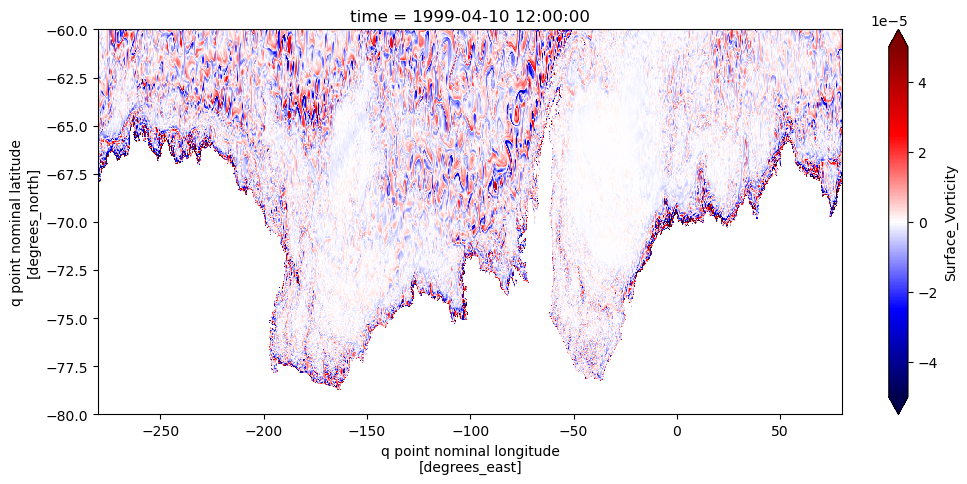

In [27]:
valmag= 5e-5
plt.figure(figsize=(12,5))
ζ_005.isel(time=100).plot(vmin=-valmag,vmax=valmag,cmap='seismic')
plt.ylim(-80,-60)

In [29]:
ζ_005.nbytes *1e-9

53.320351776

Saving panan005 vorticity field

In [30]:

ζ_005.to_netcdf(base_savedir + 'panan005_rerun/EKE_along_contour/vorticity_xyt_panan005.nc')


In [33]:
#clearing up memory 
del dUdy_005, dUs_005, dVdx_005, dVs_005, dx_xhyh_005, dx_xhyq_005
del dx_xqyh_005, dx_xqyq_005, dy_xhyh_005, dy_xhyq_005, dy_xqyh_005, dy_xqyq_005

Extracting values along the 1 km isobath

In [19]:
#panan005 daily as HT f(z,time) to colocate the isoabth points
src_p005 = '/g/data/ik11/users/wf4500/Project_panan/GH/Panan_HT_ASC/Processed_data/panan005_rerun/CSHT_month_rhoonline/*'

#importing panan01
import glob
gl =glob.glob(src_p005)
gl=sorted(gl)
p005_HTmean=xr.open_mfdataset(gl, concat_dim='time', combine='nested').mean('time').compute()

In [37]:

ζ_005_along_contour = ζ_005.interp(xq = p005_HTmean.lon_along_contour, yq =p005_HTmean.lat_along_contour)


Saving data

In [40]:

ζ_005_along_contour.to_netcdf(base_savedir + 'panan005_rerun/EKE_along_contour/vorticity_along_contour_panan005.nc')


In [42]:
#clearing up memory again
del ζ_005

### 3.2 Panan005 EKE

In [5]:
#Getting U and V at surface
Us_005 = cc.querying.getvar('panan_005deg_jra55_ryf_2024_12_14','uo',session_p005,frequency='1 daily',\
                            start_time='1999-01-01',end_time='2002-01-01',chunks={}).mean('z_l_sub01').compute()
Vs_005 = cc.querying.getvar('panan_005deg_jra55_ryf_2024_12_14','vo',session_p005,frequency='1 daily',\
                            start_time='1999-01-01',end_time='2002-01-01',chunks={}).mean('z_l_sub01').compute()


2025-02-10 14:02:49,834 - distributed.worker - ERROR - failed during get data with tcp://127.0.0.1:34433 -> None
Traceback (most recent call last):
  File "/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3.10/site-packages/tornado/iostream.py", line 861, in _read_to_buffer
    bytes_read = self.read_from_fd(buf)
  File "/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3.10/site-packages/tornado/iostream.py", line 1116, in read_from_fd
    return self.socket.recv_into(buf, len(buf))
TimeoutError: [Errno 110] Connection timed out

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3.10/site-packages/distributed/worker.py", line 1783, in get_data
    response = await comm.read(deserializers=serializers)
  File "/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3.10/site-packages/distributed/comm/tcp.py", line 236

In [6]:
#Getting U and V at surface monthly, for monthly climatology, using the 10 years of simulation
Us_005_monthly_climatology = cc.querying.getvar('panan_005deg_jra55_ryf_2024_12_14','uo',session_p005,frequency='1 monthly',\
                            start_time='1991-01-01',end_time='2002-01-01',chunks={}).isel(z_l=0).groupby('time.month').mean().compute()
Vs_005_monthly_climatology = cc.querying.getvar('panan_005deg_jra55_ryf_2024_12_14','vo',session_p005,frequency='1 monthly',\
                            start_time='1991-01-01',end_time='2002-01-01',chunks={}).isel(z_l=0).groupby('time.month').mean().compute()

2025-02-10 14:35:54,891 - distributed.utils_perf - WARNING - full garbage collections took 12% CPU time recently (threshold: 10%)
2025-02-10 14:36:00,316 - distributed.utils_perf - WARNING - full garbage collections took 12% CPU time recently (threshold: 10%)
2025-02-10 14:36:08,803 - distributed.utils_perf - WARNING - full garbage collections took 12% CPU time recently (threshold: 10%)
2025-02-10 14:36:14,600 - distributed.utils_perf - WARNING - full garbage collections took 12% CPU time recently (threshold: 10%)
2025-02-10 14:36:28,603 - distributed.utils_perf - WARNING - full garbage collections took 12% CPU time recently (threshold: 10%)
2025-02-10 14:47:31,897 - distributed.utils_perf - WARNING - full garbage collections took 11% CPU time recently (threshold: 10%)
2025-02-10 14:47:36,348 - distributed.utils_perf - WARNING - full garbage collections took 11% CPU time recently (threshold: 10%)
2025-02-10 14:47:40,662 - distributed.utils_perf - WARNING - full garbage collections took

In [7]:
#interpolating U
Us_005_qpoint = Us_005.interp(yh = Vs_005.yq).drop_vars('yh')
Us_005_qpoint_monthly_climatology = Us_005_monthly_climatology.interp(yh = Vs_005_monthly_climatology.yq).drop_vars('yh')
#interpolating v
Vs_005_qpoint = Vs_005.interp(xh = Us_005.xq).drop_vars('xh')
Vs_005_qpoint_monthly_climatology = Vs_005_monthly_climatology.interp(xh = Us_005_monthly_climatology.xq).drop_vars('xh')

In [8]:
%%time
Us_005_qpoint.load()
Us_005_qpoint_monthly_climatology.load()
print('Loading the data for a faster, less memory-intensive loop')

Loading the data for a faster, less memory-intensive loop
CPU times: user 0 ns, sys: 2.32 ms, total: 2.32 ms
Wall time: 3.1 ms


In [10]:
from tqdm import tqdm
#Calculating the anomalies from the climatology
base_savedir = '/g/data/ik11/users/wf4500/Project_panan/GH/Panan_HT_ASC/Processed_data/'
#first and last time of the month, to separate data and remove the seasonal climatology
Initial_timesstamp = Us_005_qpoint.time.resample(time ='1M').min()
Final_timesstamp = Us_005_qpoint.time.resample(time ='1M').max()
loop_extent = Final_timesstamp.shape[0] # number of indexes to loop through when doing the calculation

#Looping through months to calculate the anomaly
for n in tqdm(range(loop_extent)):
    Us_005_qpoint_thismonth = Us_005_qpoint.sel(time=slice(Initial_timesstamp[n],Final_timesstamp[n]))
    #print(Initial_timesstamp[n].time.dt.strftime('%Y-%m-%d').values.tolist()[:7])
    #here 1 is January
    month_identifier = Us_005_qpoint_thismonth.time.groupby('time.month').mean().month[0].values
    Us_005_qpoint_ano_thismonth = Us_005_qpoint_thismonth - Us_005_qpoint_monthly_climatology.sel(month = month_identifier)
    ITNC = Initial_timesstamp[n].time.dt.strftime('%Y-%m-%d').values.tolist()
    Us_005_qpoint_ano_thismonth.to_netcdf(base_savedir + 'panan005_rerun/EKE_along_contour/'+\
                                         'Uanom_xyt_' + ITNC[:7] + '_panan005.nc')

100%|██████████| 37/37 [04:56<00:00,  8.02s/it]


In [11]:

del Us_005_qpoint, Us_005_qpoint_monthly_climatology


In [12]:
%%time
Vs_005_qpoint.load()
Vs_005_qpoint_monthly_climatology.load()
print('Loading the data for a faster, less memory-intensive loop')

Loading the data for a faster, less memory-intensive loop
CPU times: user 407 μs, sys: 146 μs, total: 553 μs
Wall time: 570 μs


In [13]:
from tqdm import tqdm
#Calculating the anomalies from the climatology

#first and last time of the month, to separate data and remove the seasonal climatology
Initial_timesstamp = Vs_005_qpoint.time.resample(time ='1M').min()
Final_timesstamp = Vs_005_qpoint.time.resample(time ='1M').max()
loop_extent = Final_timesstamp.shape[0] # number of indexes to loop through when doing the calculation

#Looping through months to calculate the anomaly
for n in tqdm(range(loop_extent)):
    Vs_005_qpoint_thismonth = Vs_005_qpoint.sel(time=slice(Initial_timesstamp[n],Final_timesstamp[n]))
    #print(Initial_timesstamp[n].time.dt.strftime('%Y-%m-%d').values.tolist()[:7])
    #here 1 is January
    month_identifier = Vs_005_qpoint_thismonth.time.groupby('time.month').mean().month[0].values
    Vs_005_qpoint_ano_thismonth = Vs_005_qpoint_thismonth - Vs_005_qpoint_monthly_climatology.sel(month = month_identifier)
    ITNC = Initial_timesstamp[n].time.dt.strftime('%Y-%m-%d').values.tolist()
    Vs_005_qpoint_ano_thismonth.to_netcdf(base_savedir + 'panan005_rerun/EKE_along_contour/'+\
                                         'Vanom_xyt_' + ITNC[:7] + '_panan005.nc')

100%|██████████| 37/37 [05:23<00:00,  8.75s/it]


In [14]:
del Vs_005_qpoint, Vs_005_qpoint_monthly_climatology

In [15]:
#LOADING V AND U ANOMALIES
Vs_005_qpoint_ano = xr.open_mfdataset(base_savedir + 'panan005_rerun/EKE_along_contour/'+\
                                         'Vanom_xyt_*_panan005.nc').vo
Us_005_qpoint_ano = xr.open_mfdataset(base_savedir + 'panan005_rerun/EKE_along_contour/'+\
                                         'Uanom_xyt_*_panan005.nc').uo

Us_005_qpoint_ano.load()
Vs_005_qpoint_ano.load()


<xarray.DataArray 'vo' (time: 1096, yq: 1691, xq: 7201)> Size: 107GB
array([[[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        ...,
        [        nan, -0.04330871, -0.04496761, ..., -0.03551841,
         -0.04020057,         nan],
        [        nan, -0.03788411, -0.03973219, ..., -0.0364033 ,
         -0.03681991,         nan],
        [        nan, -0.03515053, -0.03881189, ..., -0.02378946,
         -0.02840362,         nan]],

       [[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
...
        [        nan,  0.05635698,  0.05553598, ...,  0.06736337,
          0.06112065,         nan],
        [        nan,  0.06384761,  0.06150737, ...,  0.0736695 ,
          0.06801965,         nan],
        [        nan,  0.04402286,  0.03958609, ...,  0.06489041,
          0.05788616,         nan]],

       [[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        ...,
        [        nan, -0.05273337, -0.05370802, ..., -0.03952898,
         -0.04751744,         nan],
        [        nan, -0.04806469, -0.04860683, ..., -0.03864838,
         -0.04412078,         nan],
        [        nan, -0.03776262, -0.04022199, ..., -0.0223422 ,
         -0.02089413,         nan]]])
Coordinates:
  * time     (time) object 9kB 1998-12-31 12:00:00 ... 2001-12-31 12:00:00
  * yq       (yq) float64 14kB -81.11 -81.09 -81.07 ... -37.14 -37.1 -37.06
  * xq       (xq) float64 58kB -280.0 -279.9 -279.9 -279.8 ... 79.9 79.95 80.0
    z_l      float64 8B 0.5413
    month    (time) int64 9kB 12 1 1 1 1 1 1 1 1 ... 12 12 12 12 12 12 12 12 12

In [16]:
%%time
EKE_005_surf  = 0.5 * ( (Us_005_qpoint_ano**2) + (Vs_005_qpoint_ano**2) ).compute()

CPU times: user 7min 9s, sys: 6min 9s, total: 13min 19s
Wall time: 8min 57s


(-80.0, -60.0)

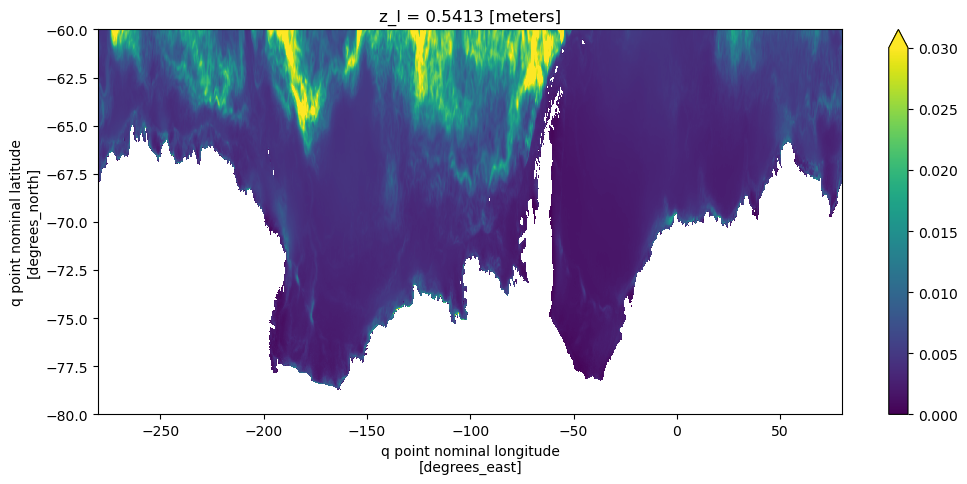

In [18]:
plt.figure(figsize=(12,5))
EKE_005_surf.mean('time').plot(vmin=0,vmax=.03)
plt.ylim(-80,-60)

Now let's extract the values along the 1 km isobath

In [20]:

EKE_005_along_contour = EKE_005_surf.interp(xq = p005_HTmean.lon_along_contour, yq =p005_HTmean.lat_along_contour)


In [21]:

EKE_005_surf.to_netcdf(base_savedir + 'panan005_rerun/EKE_along_contour/EKE_xyt_panan005.nc')


In [22]:

EKE_005_along_contour.to_netcdf(base_savedir + 'panan005_rerun/EKE_along_contour/EKE_along_contour_panan005.nc')


In [24]:
#clearing up memory
del EKE_005_along_contour, EKE_005_surf, Us_005, Us_005_qpoint, Us_005_qpoint_ano
del Us_005_qpoint_mean, Vs_005, Vs_005_qpoint, Vs_005_qpoint_ano, Vs_005_qpoint_mean

## 4. Binning EKE and vorticity into 3 degree bins

The analysis I do with the Cross slope heat transport in Panan uses a standard of 3 degree bins, to smooth out values, and to account for the effect of zonal covnergence. We to save the EKE and Vorticity data in the same 3 degree bins, to match that analysis. Note that the benning will be done as a sum for the EKE, since it is energy and can be summed in the bin, while it will be done by averaging in the Vorticity. That means that a lot of the  vorticity signal will likely be lost in the binning since in 3 degree bins we can have a huge variation between positive and negative vorticity. NEvertheless, let's save that data

In [78]:
#first, reloading the panans values along the isobath
#panan01
ζ_01_along_contour = xr.open_dataset(base_savedir + 'panan01_rerun/EKE_along_contour/vorticity_along_contour_panan01.nc').Surface_Vorticity.compute()
EKE_01_along_contour = xr.open_dataset(base_savedir + 'panan01_rerun/EKE_along_contour/EKE_along_contour_panan01.nc').__xarray_dataarray_variable__.compute()


#panan005
ζ_005_along_contour = xr.open_dataset(base_savedir + 'panan005_rerun/EKE_along_contour/vorticity_along_contour_panan005.nc').Surface_Vorticity.compute()
EKE_005_along_contour = xr.open_dataset(base_savedir + 'panan005_rerun/EKE_along_contour/EKE_along_contour_panan005.nc').__xarray_dataarray_variable__.compute()




#panan01 daily as HT f(z,time) to colocate the isoabth points
src_p01 = '/g/data/ik11/users/wf4500/Project_panan/GH/Panan_HT_ASC/Processed_data/panan01_rerun/CSHT_month_rhoonline/*'

#importing panan01
import glob
gl =glob.glob(src_p01)
gl=sorted(gl)
p01_HT=xr.open_mfdataset(gl, concat_dim='time', combine='nested').compute()
p01_HTmean=p01_HT.mean('time').compute()


#panan005 daily as HT f(z,time) to colocate the isoabth points
src_p005 = '/g/data/ik11/users/wf4500/Project_panan/GH/Panan_HT_ASC/Processed_data/panan005_rerun/CSHT_month_rhoonline/*'

#importing panan01
import glob
gl =glob.glob(src_p005)
gl=sorted(gl)
p005_HT=xr.open_mfdataset(gl, concat_dim='time', combine='nested').compute()
p005_HTmean=p005_HT.mean('time').compute()

A quick detour.... how much variability is lost by analyzing monthly EKE data....


INFO:flox:Entering _validate_reindex: reindex is None
INFO:flox:Leaving _validate_reindex: method = None, returning None
INFO:flox:_choose_engine: Choosing 'flox'

INFO:flox:Entering _validate_reindex: reindex is None
INFO:flox:Leaving _validate_reindex: method = None, returning None
INFO:flox:_choose_engine: Choosing 'flox'

INFO:flox:Entering _validate_reindex: reindex is None
INFO:flox:Leaving _validate_reindex: method = None, returning None
INFO:flox:_choose_engine: Choosing 'flox'

INFO:flox:Entering _validate_reindex: reindex is None
INFO:flox:Leaving _validate_reindex: method = None, returning None
INFO:flox:_choose_engine: Choosing 'flox'


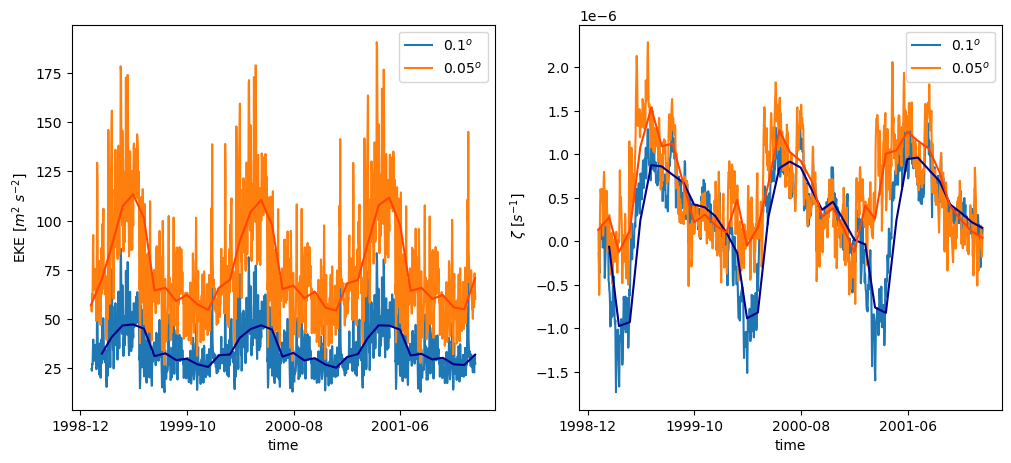

In [106]:
plt.figure(figsize = (12,5))


plt.subplot(1,2,1)
EKE_01_along_contour.sum('contour_index').plot(color='tab:blue',label=r'$0.1^o$')
EKE_005_along_contour.sum('contour_index').plot(color='tab:orange',label=r'$0.05^o$')
EKE_01_along_contour.sum('contour_index').resample(time='1M').mean().plot(color='darkblue')
EKE_005_along_contour.sum('contour_index').resample(time='1M').mean().plot(color='orangered')
plt.ylabel(r'EKE [$m^{2} \ s^{-2}$]')
plt.legend()


plt.subplot(1,2,2)

ζ_01_along_contour.mean('contour_index').plot(color='tab:blue',label=r'$0.1^o$')
ζ_005_along_contour.mean('contour_index').plot(color='tab:orange',label=r'$0.05^o$')
ζ_01_along_contour.mean('contour_index').resample(time='1M').mean().plot(color='darkblue')
ζ_005_along_contour.mean('contour_index').resample(time='1M').mean().plot(color='orangered')
plt.ylabel(r' $\zeta$ [$s^{-1}$]')
plt.legend()

It seems like a lot of variability is lost by using the monthly data. However, there still is a significant change in the total EKE along the isobath between runs. Perhaps that difference can still be of use to understand the role of EKE changes in the CSHT

Let's continue the binning

In [35]:
#corection factor for overlaying bins
factor01 = (p01_HTmean.unbinned_heat_transp_across_contour.sum() /(p01_HTmean.binned_cross_slope_heat_trans + p01_HTmean.zonal_convergence).sum()).compute()
factor005 = (p005_HTmean.unbinned_heat_transp_across_contour.sum() /(p005_HTmean.binned_cross_slope_heat_trans + p005_HTmean.zonal_convergence).sum()).compute()


For average-binning the vorticity, we will need a weight. We will use for taht the cell surface area along the isobath.

In [48]:
#importing areas
areacello_01 = cc.querying.getvar('panan01_yr2000_HTsigma','areacello',session_p01,n=1).compute()
areacello_005 = cc.querying.getvar('panan_005deg_jra55_ryf_2024_12_14','areacello',session_p005,n=1).compute()


#extracting areas along the isobath
#panan01
areacello_01  = areacello_01.sel(xh = p01_HTmean.lon_along_contour, \
                                 yh = p01_HTmean.lat_along_contour, method = 'nearest')\
.drop_vars(('xh','yh'))
#pana005
areacello_005  = areacello_005.sel(xh = p005_HTmean.lon_along_contour, \
                                 yh = p005_HTmean.lat_along_contour, method = 'nearest')\
.drop_vars(('xh','yh'))

Let's now bin the vorticity and EKE from panan01

In [107]:
# convert to longitude coordinate and average into 3 degree longitude bins:
# in degrees:
bin_width = 3
bin_spacing = 0.25
lon_west = -280
lon_east = 80
lon_along_contour = np.array(p01_HTmean.lon_along_contour)
lat_along_contour = np.array(p01_HTmean.lat_along_contour)
EKE_01_np=np.array(EKE_01_along_contour.resample(time='1M').mean())
ζ_01_np=np.array(ζ_01_along_contour.resample(time='1M').mean())
area_01_np = np.tile(np.array(areacello_01),[36,1])
# new coordinate and midpoints of longitude bins:
full_lon_coord = np.arange(lon_west,lon_east+bin_spacing,bin_spacing)
lon_bin_midpoints = np.arange(lon_west+bin_width/2,lon_east-bin_width/2,bin_spacing)
n_bin_edges = len(full_lon_coord)

# sum into longitude bins:
# need to be very careful of loops, we can't just mask over longitude values, but instead pick indices 
# on the isobath contour and sum continously along contour between defined indices.
# (i.e. lon_along_contour is not monotonic)
# find points on contour to define edges of longitude bins:
bin_edge_indices = np.zeros(n_bin_edges)
for lon_bin in range(n_bin_edges-1):
    # find first isobath point that has the right longitude:
    first_point = np.where(lon_along_contour>=full_lon_coord[lon_bin])[0][0]
    # then find all other isobath points with the same longitude as that first point:
    same_lon_points = np.where(lon_along_contour==lon_along_contour[first_point])[0]
    # we want the most southerly of these points on the same longitude line:
    bin_edge_indices[lon_bin] = same_lon_points[np.argmin(lat_along_contour[same_lon_points])]

# define east/west edges:
bin_edge_indices = bin_edge_indices.astype(int)
bin_edge_indices_west = bin_edge_indices[:-int(bin_width/bin_spacing)-1]
bin_edge_indices_east = bin_edge_indices[int(bin_width/bin_spacing):-1]
n_bins = len(bin_edge_indices_west)

# sum heat transport from isobath coord into new longitude coord:
EKE_3degbins_01 = np.zeros([36,n_bins])
for lon_bin in range(n_bins):
	EKE0 = EKE_01_np[:,bin_edge_indices_west[lon_bin]:bin_edge_indices_east[lon_bin]]
	EKE_3degbins_01[:,lon_bin] = np.sum(EKE0,axis=1)
EKE_3degbins_01 = EKE_3degbins_01 * factor01.values

# sum heat transport from isobath coord into new longitude coord:
ζ_3degbins_01 = np.zeros([36,n_bins])
for lon_bin in range(n_bins):
	ζ0 = ζ_01_np[:,bin_edge_indices_west[lon_bin]:bin_edge_indices_east[lon_bin]]
	area0 = area_01_np[:,bin_edge_indices_west[lon_bin]:bin_edge_indices_east[lon_bin]]
	ζ_3degbins_01[:,lon_bin] = (np.sum(ζ0 * area0,axis=1) / np.sum(area0,axis=1))
ζ_3degbins_01 = ζ_3degbins_01 * factor01.values


INFO:flox:Entering _validate_reindex: reindex is None
INFO:flox:Leaving _validate_reindex: method = None, returning None
INFO:flox:_choose_engine: Choosing 'flox'

INFO:flox:Entering _validate_reindex: reindex is None
INFO:flox:Leaving _validate_reindex: method = None, returning None
INFO:flox:_choose_engine: Choosing 'flox'


In [123]:
#Turning into Xarray for saving it
p01_binnedEKE = p01_HT.binned_cross_slope_heat_trans.mean('rho2_l').copy()
p01_binnedEKE.values =EKE_3degbins_01
p01_binnedEKE.name =  'EKE_binned_m2s2'


p01_unbinnedEKE = p01_HT.unbinned_heat_transp_across_contour.mean('rho2_l').copy()
p01_unbinnedEKE.values =EKE_01_np
p01_unbinnedEKE.name =  'EKE_unbinned_m2s2'


p01_binnedζ = p01_HT.binned_cross_slope_heat_trans.mean('rho2_l').copy()
p01_binnedζ.values =ζ_3degbins_01
p01_binnedζ.name =  'vorticity_binned'

p01_unbinnedζ = p01_HT.unbinned_heat_transp_across_contour.mean('rho2_l').copy()
p01_unbinnedζ.values = ζ_01_np
p01_unbinnedζ.name =  'vorticity_unbinned'

ζ_EKE_01_tosave = xr.merge((p01_unbinnedEKE,p01_binnedEKE,p01_HT.lon_along_contour,\
                         p01_HT.lat_along_contour, p01_binnedζ, p01_unbinnedζ))


In [128]:

ζ_EKE_01_tosave.to_netcdf(base_savedir + 'panan01_rerun/EKE_along_contour/vorticity_EKE_binned_along_contour_panan01.nc')



In [129]:
#clearing up memory
del ζ_EKE_01_tosave

Now lets bin and save panan005

In [137]:
# convert to longitude coordinate and average into 3 degree longitude bins:
# in degrees:
del area0, EKE0
bin_width = 3
bin_spacing = 0.25
lon_west = -280
lon_east = 80
lon_along_contour = np.array(p005_HTmean.lon_along_contour)
lat_along_contour = np.array(p005_HTmean.lat_along_contour)
EKE_005_np=np.array(EKE_005_along_contour.resample(time='1M').mean().isel(time=slice(0,-1)))
ζ_005_np=np.array(ζ_005_along_contour.resample(time='1M').mean().isel(time=slice(0,-1)))
area_005_np = np.tile(np.array(areacello_005),[36,1])
# new coordinate and midpoints of longitude bins:
full_lon_coord = np.arange(lon_west,lon_east+bin_spacing,bin_spacing)
lon_bin_midpoints = np.arange(lon_west+bin_width/2,lon_east-bin_width/2,bin_spacing)
n_bin_edges = len(full_lon_coord)

# sum into longitude bins:
# need to be very careful of loops, we can't just mask over longitude values, but instead pick indices 
# on the isobath contour and sum continously along contour between defined indices.
# (i.e. lon_along_contour is not monotonic)
# find points on contour to define edges of longitude bins:
bin_edge_indices = np.zeros(n_bin_edges)
for lon_bin in range(n_bin_edges-1):
    # find first isobath point that has the right longitude:
    first_point = np.where(lon_along_contour>=full_lon_coord[lon_bin])[0][0]
    # then find all other isobath points with the same longitude as that first point:
    same_lon_points = np.where(lon_along_contour==lon_along_contour[first_point])[0]
    # we want the most southerly of these points on the same longitude line:
    bin_edge_indices[lon_bin] = same_lon_points[np.argmin(lat_along_contour[same_lon_points])]

# define east/west edges:
bin_edge_indices = bin_edge_indices.astype(int)
bin_edge_indices_west = bin_edge_indices[:-int(bin_width/bin_spacing)-1]
bin_edge_indices_east = bin_edge_indices[int(bin_width/bin_spacing):-1]
n_bins = len(bin_edge_indices_west)

# sum heat transport from isobath coord into new longitude coord:
EKE_3degbins_005 = np.zeros([36,n_bins])
for lon_bin in range(n_bins):
	EKE0 = EKE_005_np[:,bin_edge_indices_west[lon_bin]:bin_edge_indices_east[lon_bin]]
	EKE_3degbins_005[:,lon_bin] = np.sum(EKE0,axis=1)
EKE_3degbins_005 = EKE_3degbins_005 * factor005.values

# sum heat transport from isobath coord into new longitude coord:
ζ_3degbins_005 = np.zeros([36,n_bins])
for lon_bin in range(n_bins):
	ζ0 = ζ_005_np[:,bin_edge_indices_west[lon_bin]:bin_edge_indices_east[lon_bin]]
	area0 = area_005_np[:,bin_edge_indices_west[lon_bin]:bin_edge_indices_east[lon_bin]]
	ζ_3degbins_005[:,lon_bin] = (np.sum(ζ0 * area0,axis=1) / np.sum(area0,axis=1))
ζ_3degbins_005 = ζ_3degbins_005 * factor005.values


INFO:flox:Entering _validate_reindex: reindex is None
INFO:flox:Leaving _validate_reindex: method = None, returning None
INFO:flox:_choose_engine: Choosing 'flox'

INFO:flox:Entering _validate_reindex: reindex is None
INFO:flox:Leaving _validate_reindex: method = None, returning None
INFO:flox:_choose_engine: Choosing 'flox'


In [140]:
#Turning into Xarray for saving it
p005_binnedEKE = p005_HT.binned_cross_slope_heat_trans.mean('rho2_l').copy()
p005_binnedEKE.values =EKE_3degbins_005
p005_binnedEKE.name =  'EKE_binned_m2s2'


p005_unbinnedEKE = p005_HT.unbinned_heat_transp_across_contour.mean('rho2_l').copy()
p005_unbinnedEKE.values =EKE_005_np
p005_unbinnedEKE.name =  'EKE_unbinned_m2s2'


p005_binnedζ = p005_HT.binned_cross_slope_heat_trans.mean('rho2_l').copy()
p005_binnedζ.values =ζ_3degbins_005
p005_binnedζ.name =  'vorticity_binned'

p005_unbinnedζ = p005_HT.unbinned_heat_transp_across_contour.mean('rho2_l').copy()
p005_unbinnedζ.values = ζ_005_np
p005_unbinnedζ.name =  'vorticity_unbinned'

ζ_EKE_005_tosave = xr.merge((p005_unbinnedEKE,p005_binnedEKE,p005_HT.lon_along_contour,\
                         p005_HT.lat_along_contour, p005_binnedζ, p005_unbinnedζ))


In [142]:

ζ_EKE_005_tosave.to_netcdf(base_savedir + 'panan005_rerun/EKE_along_contour/vorticity_EKE_binned_along_contour_panan005.nc')



## 5. Checking data after 3 degrees binning

How much the 3 degrees binning damps the resolution effect.

In [144]:

ζ_EKE_01_tosave = xr.open_dataset(base_savedir + 'panan01_rerun/EKE_along_contour/vorticity_EKE_binned_along_contour_panan01.nc')
ζ_EKE_005_tosave = xr.open_dataset(base_savedir + 'panan005_rerun/EKE_along_contour/vorticity_EKE_binned_along_contour_panan005.nc')




INFO:flox:Entering _validate_reindex: reindex is None
INFO:flox:Leaving _validate_reindex: method = None, returning None
INFO:flox:_choose_engine: Choosing 'flox'

INFO:flox:Entering _validate_reindex: reindex is None
INFO:flox:Leaving _validate_reindex: method = None, returning None
INFO:flox:_choose_engine: Choosing 'flox'

INFO:flox:Entering _validate_reindex: reindex is None
INFO:flox:Leaving _validate_reindex: method = None, returning None
INFO:flox:_choose_engine: Choosing 'flox'

INFO:flox:Entering _validate_reindex: reindex is None
INFO:flox:Leaving _validate_reindex: method = None, returning None
INFO:flox:_choose_engine: Choosing 'flox'


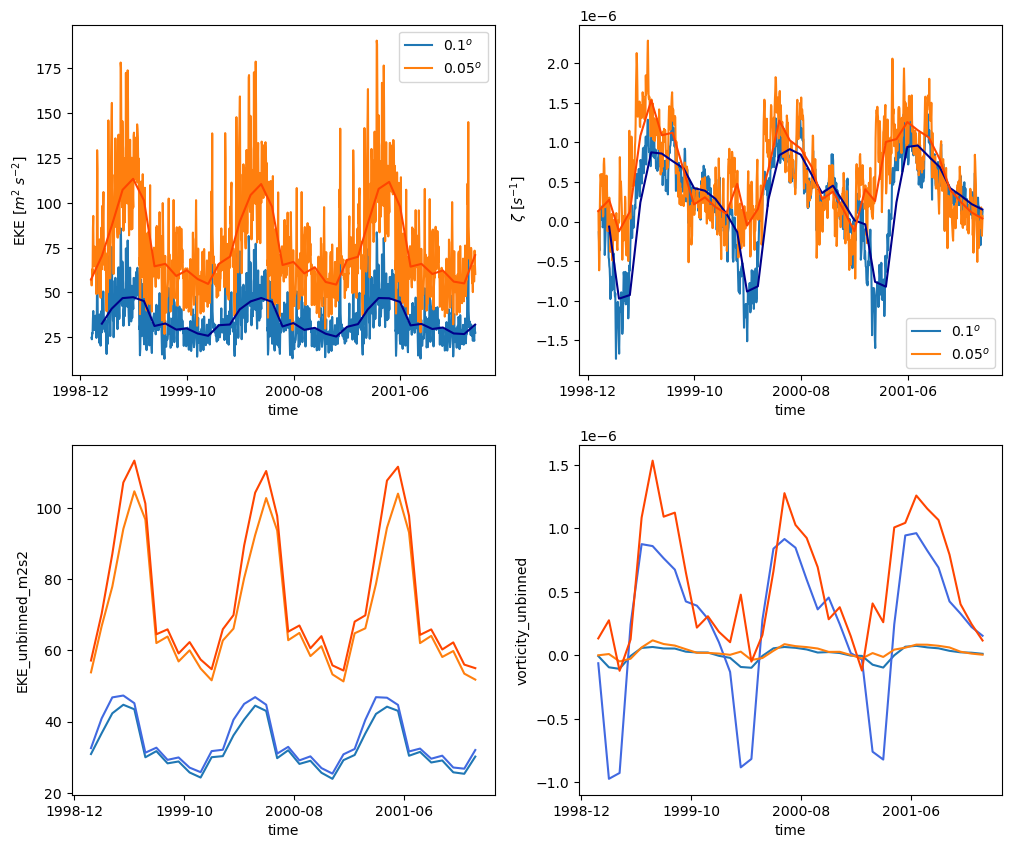

In [162]:
plt.figure(figsize = (12,10))


plt.subplot(2,2,1)
EKE_01_along_contour.sum('contour_index').plot(color='tab:blue',label=r'$0.1^o$')
EKE_005_along_contour.sum('contour_index').plot(color='tab:orange',label=r'$0.05^o$')
EKE_01_along_contour.sum('contour_index').resample(time='1M').mean().plot(color='darkblue')
EKE_005_along_contour.sum('contour_index').resample(time='1M').mean().plot(color='orangered')
plt.ylabel(r'EKE [$m^{2} \ s^{-2}$]')
plt.legend()


plt.subplot(2,2,2)

ζ_01_along_contour.mean('contour_index').plot(color='tab:blue',label=r'$0.1^o$')
ζ_005_along_contour.mean('contour_index').plot(color='tab:orange',label=r'$0.05^o$')
ζ_01_along_contour.mean('contour_index').resample(time='1M').mean().plot(color='darkblue')
ζ_005_along_contour.mean('contour_index').resample(time='1M').mean().plot(color='orangered')
plt.ylabel(r' $\zeta$ [$s^{-1}$]')
plt.legend()



plt.subplot(2,2,3)
ζ_EKE_01_tosave.EKE_binned_m2s2.sum('lon_bin_midpoints').plot(color='tab:blue',label=r'$0.1^o$')
ζ_EKE_01_tosave.EKE_unbinned_m2s2.sum('contour_index').plot(color='royalblue')
ζ_EKE_005_tosave.EKE_binned_m2s2.sum('lon_bin_midpoints').plot(color='tab:orange',label=r'$0.05^o$')
ζ_EKE_005_tosave.EKE_unbinned_m2s2.sum('contour_index').plot(color='orangered')


plt.subplot(2,2,4)
ζ_EKE_01_tosave.vorticity_binned.mean('lon_bin_midpoints').plot(color='tab:blue',label=r'$0.1^o$')
ζ_EKE_01_tosave.vorticity_unbinned.mean('contour_index').plot(color='royalblue')
ζ_EKE_005_tosave.vorticity_binned.mean('lon_bin_midpoints').plot(color='tab:orange',label=r'$0.05^o$')
ζ_EKE_005_tosave.vorticity_unbinned.mean('contour_index').plot(color='orangered')

It seems to me that the vorticity is highly affected by the binning (or wrongly binned), but not the EKE. So we should use a EKE standard for comparisson with the cross slope heat transport

## 7. Panan0025 Vorticity and EKE and Binning

This will be done separately here due to the high memory demands of this model. We will not calculate the Vorticity xyt fields

### 7.1 Panan0025 Vorticity

Panan0025 is very heavy so we will have to do that in parts

In [6]:
base_savedir = '/g/data/ik11/users/wf4500/Project_panan/GH/Panan_HT_ASC/Processed_data/'

In [6]:
%%time
#Getting U and V at surface
Us_0025 = cc.querying.getvar('mom6-panan','uo',session_p0025,frequency='1 daily',\
                            start_time='1999-01-01',end_time='2001-01-01',chunks={}).\
sel(time=slice('1999-01-01','2001-01-01')).chunk(chunks={'xq' : '1300gb'}).isel(z_l_sub01=0).compute()


CPU times: user 5min 7s, sys: 6min 19s, total: 11min 26s
Wall time: 10min 21s


In [7]:
%%time
#Getting U and V at surface
Vs_0025 = cc.querying.getvar('mom6-panan','vo',session_p0025,frequency='1 daily',\
                            start_time='1999-01-01',end_time='2001-01-01',chunks={}).\
sel(time=slice('1999-01-01','2001-01-01')).chunk(chunks={'xh' : '1300gb'}).isel(z_l_sub01=0).compute()


CPU times: user 5min 11s, sys: 5min 53s, total: 11min 4s
Wall time: 10min 4s


In [7]:
#dxs in all grid points
dx_xhyh_0025 = cc.querying.getvar('mom6-panan','dxt',session_p0025,ncfile='19990101.ocean_static.nc')
dx_xqyh_0025 = cc.querying.getvar('mom6-panan','dxCu',session_p0025,ncfile='19990101.ocean_static.nc')
dx_xhyq_0025 = cc.querying.getvar('mom6-panan','dxCv',session_p0025,ncfile='19990101.ocean_static.nc')
dx_xqyq_0025 = dx_xhyh_0025.rename({'xh':'xq','yh':'yq'}).copy()
dx_xqyq_0025 =  xr.concat([dx_xqyq_0025 [:,-1],dx_xqyq_0025 ], dim='xq')
dx_xqyq_0025['yq'] = dx_xhyq_0025.yq[:-1]
dx_xqyq_0025['xq'] = dx_xqyh_0025.xq
dx_xqyq_0025 = dx_xqyq_0025.chunk(chunks={'xq' : '1300gb'})
dx_xqyq_0025.load()

#dys in all grid points
dy_xhyh_0025 = cc.querying.getvar('mom6-panan','dyt',session_p0025,ncfile='19990101.ocean_static.nc')
dy_xqyh_0025 = cc.querying.getvar('mom6-panan','dyCu',session_p0025,ncfile='19990101.ocean_static.nc')
dy_xhyq_0025 = cc.querying.getvar('mom6-panan','dyCv',session_p0025,ncfile='19990101.ocean_static.nc')
dy_xqyq_0025 = dy_xhyh_0025.rename({'xh':'xq','yh':'yq'}).copy()
dy_xqyq_0025=  xr.concat([dy_xqyq_0025[:,-1],dy_xqyq_0025], dim='xq')
dy_xqyq_0025['yq'] = dy_xhyq_0025.yq[:-1]
dy_xqyq_0025['xq'] = dy_xqyh_0025.xq
dy_xqyq_0025 = dy_xqyq_0025.chunk(chunks={'xq' : '1300gb'})
dy_xqyq_0025.load()

print("loaded dx's and dys'")

loaded dx's and dys'


In [8]:
%%time
##### Part 1 of vorticity, dv/dx

# We need to make diff('xh') on V, but to make sure the V's are correct, a Halo is
#first created on the eastern and western side of the domain
dVs_0025 = xr.concat([Vs_0025[:,:,-1],Vs_0025,Vs_0025[:,:,0]], dim='xh').diff('xh')
#the resulting data is on xq now, so let's fix that
dVs_0025 = dVs_0025.rename({'xh':'xq'})
dVs_0025['xq'] = Us_0025.xq
dVs_0025 = dVs_0025.chunk(chunks={'xq' : '1300gb'}).compute()

FutureCancelledError: ('xarray-<this-array>-8e16e1fe84dbc7bfc91f50b1fa3872f5', 0, 0, 0) cancelled for reason: scheduler-connection-lost.
Client lost the connection to the scheduler. Please check your connection and re-run your work.

In [9]:
#now let's devide Dvs (delta done along x's) by the x distances to get dVdx.
#This velow is the first term of the vorticity
dVdx_0025 = (dVs_0025/dx_xqyq_0025)

In [11]:
%%time
##### Part 2 of vorticity, du/dy

# analogous to Dv, We need to make diff('yh') on U, but to make sure the U's 
#in this case however, we know the domain is not reentrant in y, so we can just
#make the calculation while getting rid of the Southernmost latitude.
#that is not a problem here because the Southernmost latitude is popualted by NaNs
dUs_0025 = Us_0025.diff('yh')
#the resulting data is on xq now, so let's fix that
dUs_0025 = dUs_0025.rename({'yh':'yq'})
dUs_0025['yq'] = Vs_0025.yq[1:-1]
dUs_0025 = dUs_0025.chunk(chunks={'xq' : '1300gb'}).compute()


FutureCancelledError: ('xarray-<this-array>-5cb49c640b63364a2646979170454a7f', 0, 0, 0) cancelled for reason: scheduler-connection-lost.
Client lost the connection to the scheduler. Please check your connection and re-run your work.

In [12]:
#now let's devide Dus (delta done along y's) by the y distances to get dVdx.
#This below is the second term of the vorticity
dUdy_0025 = (dUs_0025/dy_xqyq_0025)

In [14]:
ζ_0025 = dVdx_0025 - dUdy_0025
ζ_0025.name = 'Surface_Vorticity'

(-80.0, -60.0)

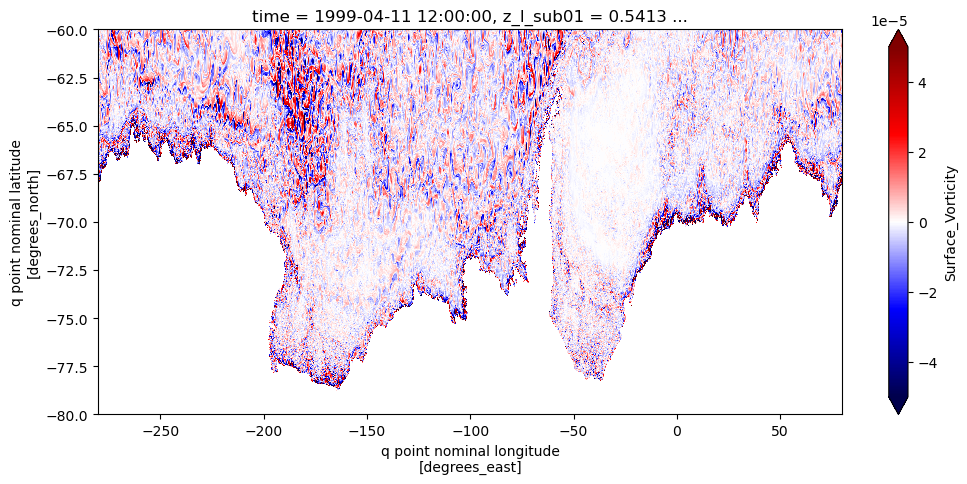

In [15]:
valmag= 5e-5
plt.figure(figsize=(12,5))
ζ_0025.isel(time=100).plot(vmin=-valmag,vmax=valmag,cmap='seismic')
plt.ylim(-80,-60)

In [50]:
ζ_0025.nbytes *1e-9

142.21621144

This file is super big. We will need to slice it into parts. I will slice it into 30 days data to save it

In [51]:
%%time
Init_time_inds = np.arange(0,732,30) #initial time indexes for slicing and saving
end_time_inds = np.append(np.arange(30,732,30),-1) #end time indexes for slicing and saving


for n in range(25):
    ζ_0025_tosave = ζ_0025.isel(time=slice(Init_time_inds[n],end_time_inds[n]))
    ζ_0025_tosave.to_netcdf(base_savedir + 'panan0025_rerun/EKE_along_contour/'+\
                            'vorticity_xyt_' + str(Init_time_inds[n]) + '_' +\
                            str(end_time_inds[n])+ '_panan0025.nc')

CPU times: user 1min 39s, sys: 3min 32s, total: 5min 12s
Wall time: 4min 7s


In [54]:
#clearing up memory 
del dUdy_0025, dUs_0025, dVdx_0025, dVs_0025, dx_xhyh_0025, dx_xhyq_0025
del dx_xqyh_0025, dx_xqyq_0025, dy_xhyh_0025, dy_xhyq_0025, dy_xqyh_0025, dy_xqyq_0025

In [11]:
#panan005 daily as HT f(z,time) to colocate the isoabth points
src_p0025 = '/g/data/ik11/users/wf4500/Project_panan/GH/Panan_HT_ASC/Processed_data/panan0025_rerun/CSHT_month_rhoonline/*'

#importing panan01
import glob
gl =glob.glob(src_p0025)
gl=sorted(gl)
p0025_HTmean=xr.open_mfdataset(gl, concat_dim='time', combine='nested').mean('time').compute()


In [56]:
%%time
ζ_0025_along_contour = ζ_0025.interp(xq = p0025_HTmean.lon_along_contour, yq =p0025_HTmean.lat_along_contour)


CPU times: user 6min 5s, sys: 4min 29s, total: 10min 35s
Wall time: 7min 7s


In [60]:

ζ_0025_along_contour.to_netcdf(base_savedir + 'panan0025_rerun/EKE_along_contour/vorticity_along_contour_panan0025.nc')


In [66]:
del ζ_0025

### 7.2 Panan0025 EKE

In [ ]:
del Us_0025, Vs_0025

In [5]:
%%time
lat_range=slice(-85,-56)
#Getting U and V at surface
Us_0025 = cc.querying.getvar('mom6-panan','uo',session_p0025,frequency='1 daily',\
                            start_time='1999-01-01',end_time='2002-01-01',chunks={}).\
sel(time=slice('1999-01-01','2002-01-01')).sel(yh=lat_range).chunk(chunks={'xq' : '1300gb'}).isel(z_l_sub01=0).compute()


CPU times: user 5min 36s, sys: 6min 7s, total: 11min 44s
Wall time: 11min 11s


In [6]:
%%time
#importing yq for interpolation
yq = cc.querying.getvar('mom6-panan','yq',session_p0025,n=1).sel(yq=lat_range).compute()
#interpolating U
Us_0025_qpoint = Us_0025.interp(yh = yq).drop_vars('yh')



CPU times: user 21min 13s, sys: 17min 54s, total: 39min 7s
Wall time: 26min 37s


In [7]:
del Us_0025

Now the $U$ monthly mean

In [8]:
#Getting U and V at surface monthly, for monthly climatology, using the 10 years of simulation
Us_0025_monthly_climatology = cc.querying.getvar('mom6-panan','uo',session_p0025,frequency='1 monthly',\
                            start_time='1991-01-01',end_time='2002-01-01',chunks={}).isel(z_l=0).groupby('time.month').mean().compute()


In [9]:

Us_0025_qpoint_monthly_climatology = Us_0025_monthly_climatology.interp(yh = yq).drop_vars('yh')


In [14]:
del Us_0025_monthly_climatology

In [10]:
%%time
Us_0025_qpoint.load()
Us_0025_qpoint_monthly_climatology.load()
print('Loading the data for a faster, less memory-intensive loop')

Loading the data for a faster, less memory-intensive loop
CPU times: user 0 ns, sys: 227 μs, total: 227 μs
Wall time: 241 μs


In [16]:
from tqdm import tqdm
#Calculating the anomalies from the climatology
base_savedir = '/g/data/ik11/users/wf4500/Project_panan/GH/Panan_HT_ASC/Processed_data/'
#first and last time of the month, to separate data and remove the seasonal climatology
Initial_timesstamp = Us_0025_qpoint.time.resample(time ='1M').min()
Final_timesstamp = Us_0025_qpoint.time.resample(time ='1M').max()
loop_extent = Final_timesstamp.shape[0] # number of indexes to loop through when doing the calculation

#Looping through months to calculate the anomaly
for n in tqdm(range(loop_extent)):
    Us_0025_qpoint_thismonth = Us_0025_qpoint.sel(time=slice(Initial_timesstamp[n],Final_timesstamp[n]))
    #print(Initial_timesstamp[n].time.dt.strftime('%Y-%m-%d').values.tolist()[:7])
    #here 1 is January
    month_identifier = Us_0025_qpoint_thismonth.time.groupby('time.month').mean().month[0].values
    Us_0025_qpoint_ano_thismonth = Us_0025_qpoint_thismonth - Us_0025_qpoint_monthly_climatology.sel(month = month_identifier)
    ITNC = Initial_timesstamp[n].time.dt.strftime('%Y-%m-%d').values.tolist()
    Us_0025_qpoint_ano_thismonth.to_netcdf(base_savedir + 'panan0025_rerun/EKE_along_contour/'+\
                                         'Uanom_xyt_' + ITNC[:7] + '_panan0025.nc')



100%|██████████| 36/36 [16:37<00:00, 27.70s/it]


Cleaning up memory to calculate $V'$

In [17]:

del Us_0025_qpoint, Us_0025_qpoint_monthly_climatology

Starting $V'$ calculation

In [18]:
%%time
#Getting U and V at surface
Vs_0025 = cc.querying.getvar('mom6-panan','vo',session_p0025,frequency='1 daily',\
                            start_time='1999-01-01',end_time='2002-01-01',chunks={}).\
sel(time=slice('1999-01-01','2002-01-01')).sel(yq=lat_range).chunk(chunks={'xh' : '1300gb'}).isel(z_l_sub01=0).compute()


CPU times: user 4min 53s, sys: 5min 24s, total: 10min 17s
Wall time: 9min 36s


In [21]:
#interpolating v
#importing yq for interpolation
xq = cc.querying.getvar('mom6-panan','xq',session_p0025,n=1).compute()

Vs_0025_qpoint = Vs_0025.interp(xh = xq).drop_vars('xh')

In [22]:
del Vs_0025

In [23]:
#Getting U and V at surface monthly, for monthly climatology, using the 10 years of simulation
Vs_0025_monthly_climatology = cc.querying.getvar('mom6-panan','vo',session_p0025,frequency='1 monthly',\
                            start_time='1991-01-01',end_time='2002-01-01',chunks={}).isel(z_l=0).groupby('time.month').mean().compute()


In [24]:
#interpolating v
Vs_0025_qpoint_monthly_climatology = Vs_0025_monthly_climatology.interp(xh = xq).drop_vars('xh')

In [25]:
%%time
Vs_0025_qpoint.load()
Vs_0025_qpoint_monthly_climatology.load()
print('Loading the data for a faster, less memory-intensive loop')

Loading the data for a faster, less memory-intensive loop
CPU times: user 250 μs, sys: 0 ns, total: 250 μs
Wall time: 265 μs


In [26]:
#Calculating the anomalies from the climatology
base_savedir = '/g/data/ik11/users/wf4500/Project_panan/GH/Panan_HT_ASC/Processed_data/'
#first and last time of the month, to separate data and remove the seasonal climatology
Initial_timesstamp = Vs_0025_qpoint.time.resample(time ='1M').min()
Final_timesstamp = Vs_0025_qpoint.time.resample(time ='1M').max()
loop_extent = Final_timesstamp.shape[0] # number of indexes to loop through when doing the calculation

#Looping through months to calculate the anomaly
for n in tqdm(range(loop_extent)):
    Vs_0025_qpoint_thismonth = Vs_0025_qpoint.sel(time=slice(Initial_timesstamp[n],Final_timesstamp[n]))
    #print(Initial_timesstamp[n].time.dt.strftime('%Y-%m-%d').values.tolist()[:7])
    #here 1 is January
    month_identifier = Vs_0025_qpoint_thismonth.time.groupby('time.month').mean().month[0].values
    Vs_0025_qpoint_ano_thismonth = Vs_0025_qpoint_thismonth - Vs_0025_qpoint_monthly_climatology.sel(month = month_identifier)
    ITNC = Initial_timesstamp[n].time.dt.strftime('%Y-%m-%d').values.tolist()
    Vs_0025_qpoint_ano_thismonth.to_netcdf(base_savedir + 'panan0025_rerun/EKE_along_contour/'+\
                                         'Vanom_xyt_' + ITNC[:7] + '_panan0025.nc')



100%|██████████| 36/36 [22:45<00:00, 37.94s/it]


Deleting data to clear out memory

In [27]:
del Vs_0025_qpoint, Vs_0025_qpoint_monthly_climatology

And now importing it again to calculate EKE

In [6]:
#LOADING V AND U ANOMALIES
base_savedir = '/g/data/ik11/users/wf4500/Project_panan/GH/Panan_HT_ASC/Processed_data/'

Vs_0025_qpoint_ano = xr.open_mfdataset(base_savedir + 'panan0025_rerun/EKE_along_contour/'+\
                                         'Vanom_xyt_*_panan0025.nc').vo
Us_0025_qpoint_ano = xr.open_mfdataset(base_savedir + 'panan0025_rerun/EKE_along_contour/'+\
                                         'Uanom_xyt_*_panan0025.nc').uo

Us_0025_qpoint_ano.load()
Vs_0025_qpoint_ano.load()


<xarray.DataArray 'vo' (time: 1095, yq: 2262, xq: 14401)> Size: 285GB
array([[[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        ...,
        [        nan, -0.20475066, -0.20517362, ..., -0.16906938,
         -0.18241251,         nan],
        [        nan, -0.2093575 , -0.20848721, ..., -0.1757467 ,
         -0.18940469,         nan],
        [        nan, -0.21384322, -0.2126636 , ..., -0.18131174,
         -0.19553364,         nan]],

       [[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
...
        [        nan,  0.03928616,  0.04531408, ...,  0.01010924,
          0.01911456,         nan],
        [        nan,  0.03432888,  0.04326965, ...,  0.01076772,
          0.0182277 ,         nan],
        [        nan,  0.0316156 ,  0.04231937, ...,  0.00410274,
          0.01116816,         nan]],

       [[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        ...,
        [        nan,  0.03194443,  0.03971295, ..., -0.00545605,
          0.00656501,         nan],
        [        nan,  0.02663362,  0.03775997, ..., -0.00541948,
          0.00524428,         nan],
        [        nan,  0.02347632,  0.03664193, ..., -0.01266062,
         -0.00243759,         nan]]])
Coordinates:
  * time       (time) object 9kB 1999-01-01 12:00:00 ... 2001-12-31 12:00:00
  * yq         (yq) float64 18kB -81.1 -81.09 -81.08 ... -56.03 -56.01 -56.0
  * xq         (xq) float64 115kB -280.0 -280.0 -279.9 ... 79.95 79.97 80.0
    z_l_sub01  float64 8B 0.5413
    z_l        float64 8B 0.5413
    month      (time) int64 9kB 1 1 1 1 1 1 1 1 1 ... 12 12 12 12 12 12 12 12 12

Finally calculating EKE

In [ ]:
%%time
EKE_0025_surf  = 0.5 * ( (Us_0025_qpoint_ano**2) + (Vs_0025_qpoint_ano**2) ).compute()

Sanity check

(-80.0, -60.0)

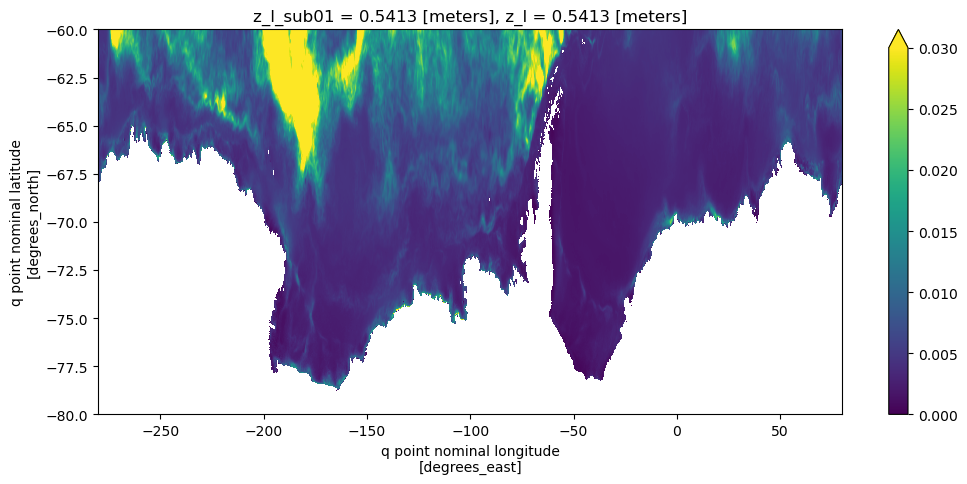

In [14]:
plt.figure(figsize=(12,5))
EKE_0025_surf.mean('time').plot(vmin=0,vmax=.03)
plt.ylim(-80,-60)

In [9]:
%%time
base_savedir = '/g/data/ik11/users/wf4500/Project_panan/GH/Panan_HT_ASC/Processed_data/'
Init_time_inds = np.arange(0,1095,30) #initial time indexes for slicing and saving
end_time_inds = np.append(np.arange(30,1095,30),-1) #end time indexes for slicing and saving


for n in range(37):
    EKE_0025_surf_tosave = EKE_0025_surf.isel(time=slice(Init_time_inds[n],end_time_inds[n]))
    EKE_0025_surf_tosave.to_netcdf(base_savedir + 'panan0025_rerun/EKE_along_contour/'+\
                            'EKE_xyt_' + str(Init_time_inds[n]).zfill(5) + '_' +\
                            str(end_time_inds[n]).zfill(5)+ '_panan0025.nc')



CPU times: user 3min 25s, sys: 7min 53s, total: 11min 19s
Wall time: 8min 57s


In [12]:
%%time
EKE_0025_surf_along_contour = EKE_0025_surf.interp(xq = p0025_HTmean.lon_along_contour, yq =p0025_HTmean.lat_along_contour)


CPU times: user 9min 59s, sys: 8min 37s, total: 18min 36s
Wall time: 12min 35s


In [13]:

EKE_0025_surf_along_contour.to_netcdf(base_savedir + 'panan0025_rerun/EKE_along_contour/EKE_along_contour_panan0025.nc')
